# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [727]:

import matplotlib
import os
import pandas as pd
import glob
import torch
import numpy as np
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import matplotlib.pyplot as plt

In [728]:
folder_path = r"Myiborus_nests/data/incubation_myioborus/Processed"
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

In [729]:
dataframes = {}

# Leer cada archivo y guardarlo en el diccionario
for file in csv_files:
    file_name = os.path.splitext(os.path.basename(file))[0]
    df = pd.read_csv(file)
    dataframes[file_name] = df

# Ver cuántos archivos se importaron y mostrar los nombres
print(f"Se importaron {len(dataframes)} archivos.")
print("Archivos importados:")
for name in dataframes:
    print(name)

Se importaron 47 archivos.
Archivos importados:
Myioborus_melanocephalus_TU1a_DOR08_NEST_processed
Myioborus_melanocephalus_W1a_JAB08_EGG_processed
Myioborus_melanocephalus_w1a_nap08_EGG_processed
Myioborus_melanocephalus_W1a_wjm08_processed
Myioborus_melanocephalus_W1b_DOR11_EGG_processed
Myioborus_melanocephalus_W1b_JAB08_processed
Myioborus_melanocephalus_W1c_DOR11_EGG_processed
Myioborus_miniatus_SP12a_RVA10_EGG_processed
Myioborus_miniatus_SP12b_RVA10_EGG_processed
Myioborus_miniatus_SP12c_RVA10_EGG_processed
Myioborus_miniatus_SP1a_MCE08_EGG_processed
Myioborus_miniatus_SP1b_MCE08_EGGbutbadtemp_processed
Myioborus_miniatus_SP1_DAR11_EGG_processed
Myioborus_miniatus_SP2a_DOR09_EGG_processed
Myioborus_miniatus_SP2b_DOR09_EGG_processed
Myioborus_miniatus_SPR01_JCB09_EGG_processed
Myioborus_miniatus_TA02a_CA15_processed
Myioborus_miniatus_TA02a_RA15_processed
Myioborus_miniatus_TA04A_MB15_processed
Myioborus_miniatus_TA04a_RVA14_processed
Myioborus_miniatus_TA04B_MB15_processed
Myiob

In [730]:
# Diccionarios para almacenar los datasets por tipo
datasets_egg = {}
datasets_nest = {}

for file in csv_files:
    df = pd.read_csv(file)
    file_name = os.path.splitext(os.path.basename(file))[0]

    columns_lower = df.columns.str.lower()

    has_nest = any('nest' in col for col in columns_lower)
    has_egg = any('egg' in col for col in columns_lower)

    if has_nest and has_egg:
        # Identificar columnas
        id_cols = [col for col in df.columns if col in ['#', 'Date-time']]
        egg_cols = [col for col in df.columns if 'egg' in col.lower()]
        nest_cols = [col for col in df.columns if 'nest' in col.lower()]
        other_cols = [col for col in df.columns if col not in id_cols + egg_cols + nest_cols]

        # Crear DataFrames reordenados
        df_egg = df[id_cols + egg_cols + other_cols].copy()
        df_nest = df[id_cols + nest_cols + other_cols].copy()

        datasets_egg[file_name + "_EGG"] = df_egg
        datasets_nest[file_name + "_NEST"] = df_nest

    elif has_egg:
        id_cols = [col for col in df.columns if col in ['#', 'Date-time']]
        egg_cols = [col for col in df.columns if 'egg' in col.lower()]
        other_cols = [col for col in df.columns if col not in id_cols + egg_cols]
        df_egg = df[id_cols + egg_cols + other_cols].copy()
        datasets_egg[file_name] = df_egg

    elif has_nest:
        datasets_nest[file_name] = df

    else:
        print(f"Archivo sin columnas 'EGG' ni 'NEST': {file_name}")

# Ver resumen
print(f"Archivos con datos EGG: {len(datasets_egg)}")
print(f"Archivos con datos NEST: {len(datasets_nest)}")

Archivos con datos EGG: 15
Archivos con datos NEST: 47


In [731]:
datasets_egg

{'Myioborus_melanocephalus_W1a_JAB08_EGG_processed_EGG':          #         Date-time     egg  Ambient
 0        2   11/19/2008 8:04  21.390   32.665
 1        3   11/19/2008 8:05  12.751   12.703
 2        4   11/19/2008 8:06  11.977   12.678
 3        5   11/19/2008 8:07  10.883   12.437
 4        6   11/19/2008 8:08   8.941   12.461
 ...    ...               ...     ...      ...
 2995  2997   11/21/2008 9:59  46.067   70.626
 2996  2998  11/21/2008 10:00  45.908   72.119
 2997  2999  11/21/2008 10:01  45.342   69.792
 2998  3000  11/21/2008 10:02  46.162   71.480
 2999  3001  11/21/2008 10:03   5.693   44.411
 
 [3000 rows x 4 columns],
 'Myioborus_melanocephalus_w1a_nap08_EGG_processed_EGG':            #        Date-time     egg  Ambient
 0          2  10/22/2008 9:01  13.810   16.773
 1          3  10/22/2008 9:02  13.786   17.486
 2          4  10/22/2008 9:03  13.786   17.605
 3          5  10/22/2008 9:04  13.786   17.796
 4          6  10/22/2008 9:05  13.786   16.677
 ...    

In [732]:
datasets_nest

{'Myioborus_melanocephalus_TU1a_DOR08_NEST_processed':            #        Date-time    Nest  Ambient
 0          1  8/14/2008 10:01  17.034   14.625
 1          2  8/14/2008 10:02  17.011   14.601
 2          3  8/14/2008 10:03  17.058   14.649
 3          4  8/14/2008 10:04  17.082   14.625
 4          5  8/14/2008 10:05  17.082   14.673
 ...      ...              ...     ...      ...
 15994  15995  8/25/2008 12:35  17.534   14.098
 15995  15996  8/25/2008 12:36  17.368   13.906
 15996  15997  8/25/2008 12:37  17.415   13.978
 15997  15998  8/25/2008 12:38  17.368   13.978
 15998  15999  8/25/2008 12:39  18.057   13.690
 
 [15999 rows x 4 columns],
 'Myioborus_melanocephalus_W1a_JAB08_EGG_processed_NEST':          #         Date-time    Nest  Ambient
 0        2   11/19/2008 8:04  21.533   32.665
 1        3   11/19/2008 8:05  19.674   12.703
 2        4   11/19/2008 8:06  18.866   12.678
 3        5   11/19/2008 8:07  18.319   12.437
 4        6   11/19/2008 8:08  17.867   12.461
 .

In [733]:
# Combinar datasets y añadir sufijo solo a los verdaderos egg
datasets_combinados = {}

for nombre, df in datasets_egg.items():
    datasets_combinados[nombre + "_soloegg"] = df  # para evitar confusión

for nombre, df in datasets_nest.items():
    datasets_combinados[nombre] = df

In [734]:
batch_size = 16  # <-- asegúrate de mantener esta línea
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load the model

In [735]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BiLSTM(torch.nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiLSTM, self).__init__()
        self.lstm = torch.nn.LSTM(input_size, hidden_size, num_layers,
                                  batch_first=True, bidirectional=True)
        self.fc = torch.nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return out

modelo_final = BiLSTM(input_size=3, hidden_size=64, num_layers=2, num_classes=3)
modelo_final.load_state_dict(torch.load("D:\Myiborus\models\modelo_entrenado_final_total.pth", map_location=device))
modelo_final.to(device)
modelo_final.eval()

BiLSTM(
  (lstm): LSTM(3, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [736]:
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

datasets_egg = {}
datasets_nest = {}

for file in csv_files:
    df = pd.read_csv(file)
    file_name = os.path.splitext(os.path.basename(file))[0]
    columns_lower = df.columns.str.lower()

    has_nest = any('nest' in col for col in columns_lower)
    has_egg = any('egg' in col for col in columns_lower)

    id_cols = [col for col in df.columns if col.lower() in ['#', 'date-time']]
    egg_cols = [col for col in df.columns if 'egg' in col.lower()]
    nest_cols = [col for col in df.columns if 'nest' in col.lower()]
    other_cols = [col for col in df.columns if col not in id_cols + egg_cols + nest_cols]

    if has_egg:
        df_egg = df[id_cols + egg_cols + other_cols].copy()
        datasets_egg[file_name + "_soloegg"] = df_egg
    if has_nest:
        df_nest = df[id_cols + nest_cols + other_cols].copy()
        datasets_nest[file_name] = df_nest

# Unir en un solo diccionario con IDs únicos
datasets_combinados = {**datasets_egg, **datasets_nest}

# === Dataset para DataLoader ===
class BloqueDataset(Dataset):
    def __init__(self, bloques):
        self.bloques = bloques
    def __len__(self):
        return len(self.bloques)
    def __getitem__(self, idx):
        return torch.tensor(self.bloques[idx], dtype=torch.float32)

# === División en bloques diarios con hour_sin ===
def dividir_en_bloques(df):
    df['hour_sin'] = np.sin(2 * np.pi * df['tiempo'] / 1440)
    bloques = []
    for i in range(0, len(df), 1440):
        bloque = df.iloc[i:i+1440]
        if len(bloque) == 1440:
            X = bloque[['egg', 'ambient', 'hour_sin']].to_numpy()
            bloques.append(X)
    return np.array(bloques)

In [737]:
resultados = []
batch_size = 16  # Asegúrate de definir esto antes del bucle

for nombre_archivo, df in tqdm(datasets_combinados.items()):
    df.columns = [col.lower() for col in df.columns]

    if 'date-time' in df.columns:
        df = df.rename(columns={'date-time': 'tiempo'})

    if not all(col in df.columns for col in ['tiempo']) or \
       not any(col in df.columns for col in ['egg', 'nest']):
        print(f"❌ Saltando {nombre_archivo} - columnas incompletas")
        continue

    if 'egg' in df.columns:
        df = df[['egg', 'ambient', 'tiempo']]
    elif 'nest' in df.columns:
        df = df[['nest', 'ambient', 'tiempo']]
        df = df.rename(columns={'nest': 'egg'})  # unificar para el modelo

    # Convertir y ordenar por tiempo real
    if not np.issubdtype(df['tiempo'].dtype, np.number):
        df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce')
        df = df.dropna(subset=['tiempo'])
        df = df.sort_values('tiempo')  # 🚨 ESTA LÍNEA ES LA CLAVE
        df['tiempo'] = df['tiempo'].dt.hour * 60 + df['tiempo'].dt.minute

    bloques = dividir_en_bloques(df)
    if len(bloques) == 0:
        print(f"⚠️  {nombre_archivo} no tiene bloques completos de 1440 minutos.")
        continue

    dataset = BloqueDataset(bloques)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for i, batch in enumerate(loader):
            batch = batch.to(device)
            salida = modelo_final(batch)
            preds = torch.argmax(salida, dim=2).cpu().numpy()

            for j, pred in enumerate(preds):
                for minuto, etiqueta in enumerate(pred):
                    resultados.append({
                        "archivo": nombre_archivo,
                        "dia": i * batch_size + j,
                        "minuto": minuto,
                        "prediccion": int(etiqueta)
                    })


 53%|█████▎    | 33/62 [00:05<00:04,  6.66it/s]C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\1145630988.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce')
 74%|███████▍  | 46/62 [00:07<00:02,  5.97it/s]C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\1145630988.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce')
 97%|█████████▋| 60/62 [00:10<00:00,  7.45it/s]C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\1145630988.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, pl

In [738]:
import random

In [739]:
def plot_prediccion_con_temperatura(df_resultados, datasets_combinados):
    # Elegir aleatoriamente un archivo y un día válido
    archivos_validos = df_resultados['archivo'].unique()
    archivo_id = random.choice(archivos_validos)
    dias_validos = df_resultados[df_resultados['archivo'] == archivo_id]['dia'].unique()
    dia = random.choice(dias_validos)

    # Subset de predicciones
    df_plot = df_resultados[
        (df_resultados['archivo'] == archivo_id) &
        (df_resultados['dia'] == dia)
    ]

    if df_plot.empty or archivo_id not in datasets_combinados:
        print(f"❌ No se encontraron datos para {archivo_id} día {dia}")
        return

    # Cargar el dataframe original y prepararlo
    df = datasets_combinados[archivo_id].copy()
    df.columns = [col.lower() for col in df.columns]
    df = df.rename(columns={'date-time': 'tiempo'} if 'date-time' in df.columns else {})

    if 'nest' in df.columns:
        df = df.rename(columns={'nest': 'egg'})

    # Parsear tiempo
    df['tiempo'] = pd.to_datetime(df['tiempo'], errors='coerce')
    df = df.dropna(subset=['tiempo'])
    df = df.sort_values('tiempo')
    df['tiempo_min'] = df['tiempo'].dt.hour * 60 + df['tiempo'].dt.minute

    # Seleccionar el bloque correspondiente al día
    start_idx = dia * 1440
    end_idx = start_idx + 1440
    if end_idx > len(df):
        print(f"⚠️ Día {dia} excede la cantidad de datos disponibles en {archivo_id}")
        return
    df_day = df.iloc[start_idx:end_idx].copy()
    df_day = df_day.reset_index(drop=True)

    # Añadir predicción
    df_day['prediccion'] = df_plot.sort_values('minuto')['prediccion'].values

    colores = {
        0: '#333E48',  # Nocturnal
        1: '#535AA6',  # Off
        2: '#E28342',  # On
    }


    etiquetas = {
        0: 'Nocturnal',
        1: 'Off',
        2: 'On'
    }

    plt.figure(figsize=(18, 4))
   # plt.plot(df_day['tiempo_min'], df_day['egg'], label="Temperatura Egg", color='black', alpha=0.4)

    for clase in df_day['prediccion'].unique():
        mask = df_day['prediccion'] == clase
        plt.scatter(df_day.loc[mask, 'tiempo_min'], df_day.loc[mask, 'egg'],
                    color=colores[clase], label=etiquetas[clase], s=10)

    plt.title(f"Archivo: {archivo_id} - Día {dia}")
    plt.xlabel("Minuto del día")
    plt.ylabel("Temperatura (°C)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [740]:
df_resultados = pd.DataFrame(resultados)

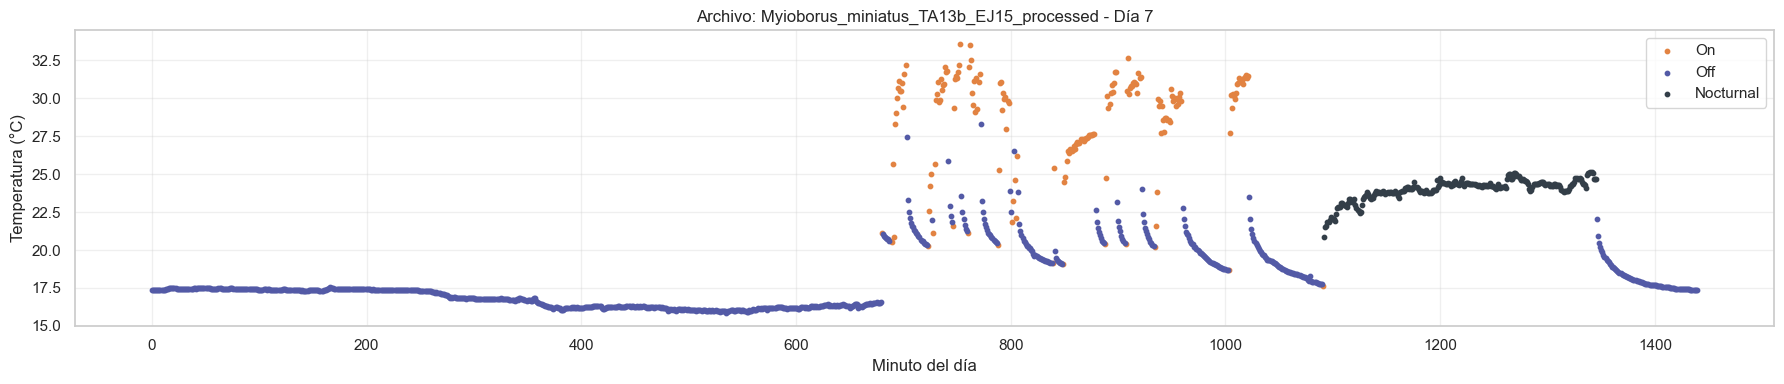

In [741]:
plot_prediccion_con_temperatura(df_resultados, datasets_combinados)

In [742]:
df_resultados

,archivo,dia,minuto,prediccion
0,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,0,2
1,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,1,1
2,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,2,1
3,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,3,1
4,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,4,1
...,...,...,...,...
472315,Myoburus_miniatus_TA11a_SF15_processed,1,1435,1
472316,Myoburus_miniatus_TA11a_SF15_processed,1,1436,1
472317,Myoburus_miniatus_TA11a_SF15_processed,1,1437,1
472318,Myoburus_miniatus_TA11a_SF15_processed,1,1438,1


In [743]:
import numpy as np
from pathlib import Path


In [744]:
carpeta_filtrada = "data/testing"
archivos_ok = os.listdir(carpeta_filtrada)

# Extraer pares (archivo_id, dia) desde nombres como "Myioborus_minia_DIA3.png"
nombres_ok = []
for f in archivos_ok:
    if f.endswith(".png"):
        stem = Path(f).stem
        if "_DIA" in stem:
            archivo, dia = stem.rsplit("_DIA", 1)
            nombres_ok.append((archivo, int(dia)))

set_aceptados = set(nombres_ok)

# Filtrar resultados
df_filtrado = df_resultados[
    df_resultados.apply(lambda row: (row['archivo'], row['dia']) in set_aceptados, axis=1)
]

# Guardar como CSV
df_filtrado.to_csv("resultados_filtrados.csv", index=False)
print(f"✅ Exportado {len(df_filtrado)} filas a 'resultados_filtrados.csv'")

✅ Exportado 388800 filas a 'resultados_filtrados.csv'


In [745]:
def corregir_nocturnal_entre_on(df, max_duracion_nocturnal=120):
    """
    Corrige Nocturnal alucinados solo cuando aparecen como islas dentro del comportamiento diurno.

    Regla:
    Para cada archivo y día:
    - Detecta segmentos consecutivos de la misma predicción.
    - Si un segmento Nocturnal está entre dos segmentos On,
      y su duración es menor o igual a max_duracion_nocturnal,
      se convierte en On.

    Códigos:
    0 = Nocturnal
    1 = Off
    2 = On
    """

    df_corr = df.copy()

    for (archivo, dia), idx in df_corr.groupby(['archivo', 'dia']).groups.items():
        grupo = df_corr.loc[idx].sort_values('minuto').copy()

        pred = grupo['prediccion'].to_numpy()
        indices = grupo.index.to_numpy()

        # Crear segmentos consecutivos
        segmentos = []
        inicio = 0

        for i in range(1, len(pred)):
            if pred[i] != pred[i - 1]:
                segmentos.append({
                    'start': inicio,
                    'end': i - 1,
                    'label': pred[i - 1],
                    'duration': i - inicio
                })
                inicio = i

        segmentos.append({
            'start': inicio,
            'end': len(pred) - 1,
            'label': pred[-1],
            'duration': len(pred) - inicio
        })

        # Revisar solo segmentos internos, no el primero ni el último
        for s in range(1, len(segmentos) - 1):
            seg = segmentos[s]
            prev_seg = segmentos[s - 1]
            next_seg = segmentos[s + 1]

            if (
                seg['label'] == 0 and
                prev_seg['label'] in [1, 2] and
                next_seg['label'] in [1, 2] and
                seg['duration'] <= max_duracion_nocturnal
            ):
                idx_convertir = indices[seg['start']:seg['end'] + 1]
                df_corr.loc[idx_convertir, 'prediccion'] = 2

    return df_corr

In [746]:
filas_completas = []

for (archivo, dia), grupo in df_filtrado.groupby(['archivo', 'dia']):
    if archivo not in datasets_combinados:
        continue

    df_orig = datasets_combinados[archivo].copy()
    df_orig.columns = [col.lower() for col in df_orig.columns]
    df_orig = df_orig.rename(columns={'date-time': 'tiempo'} if 'date-time' in df_orig.columns else {})
    if 'nest' in df_orig.columns:
        df_orig = df_orig.rename(columns={'nest': 'egg'})

    df_orig['tiempo'] = pd.to_datetime(df_orig['tiempo'], errors='coerce')
    df_orig = df_orig.dropna(subset=['tiempo']).sort_values('tiempo')
    df_orig['tiempo_min'] = df_orig['tiempo'].dt.hour * 60 + df_orig['tiempo'].dt.minute

    start_idx = dia * 1440
    end_idx = start_idx + 1440

    if end_idx <= len(df_orig):
        df_day = df_orig.iloc[start_idx:end_idx].copy().reset_index(drop=True)
        df_preds = grupo.sort_values('minuto').reset_index(drop=True)

        # Concatenar columnas
        df_day = df_day.loc[:len(df_preds) - 1]  # recorte de seguridad
        df_preds = df_preds.loc[:len(df_day) - 1]

        df_day['archivo'] = archivo
        df_day['dia'] = dia
        df_day['minuto'] = df_preds['minuto']
        df_day['prediccion'] = df_preds['prediccion']

        filas_completas.append(df_day)

# Combinar todos los días aceptados en un solo DataFrame completo
df_filtrado_completo = pd.concat(filas_completas, ignore_index=True)

df_filtrado_completo_raw = df_filtrado_completo.copy()

df_filtrado_completo = corregir_nocturnal_entre_on(
    df_filtrado_completo,
    max_duracion_nocturnal=120
)


C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\3007185430.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_orig['tiempo'] = pd.to_datetime(df_orig['tiempo'], errors='coerce')
C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\3007185430.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_orig['tiempo'] = pd.to_datetime(df_orig['tiempo'], errors='coerce')
C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\3007185430.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_orig['tiempo'] = pd.to_datetime(df_orig['tiempo'], errors='coerce')
C:\Users\jorge\AppData\Lo

In [747]:
# ============================================================
# Reconstruct true calendar days from accepted 24h blocks
# Keep only complete midnight-to-midnight calendar days
# ============================================================

df_export = df_filtrado_completo.copy()

df_export["tiempo"] = pd.to_datetime(df_export["tiempo"], errors="coerce")
df_export = df_export.dropna(subset=["tiempo"]).copy()

# Keep the original DL/block day
df_export["block_dia"] = df_export["dia"].astype(int)
df_export["block_minute"] = df_export["minuto"].astype(int)

# Real calendar date and real clock minute
df_export["calendar_date"] = df_export["tiempo"].dt.date.astype(str)
df_export["clock_minute"] = (
    df_export["tiempo"].dt.hour * 60 +
    df_export["tiempo"].dt.minute
).astype(int)

# Binary rhythm:
# 1 = On + Nocturnal
# 0 = Off
df_export["incubating"] = np.where(df_export["prediccion"].isin([0, 2]), 1, 0).astype(int)

# Check complete calendar days
calendar_counts = (
    df_export
    .groupby(["archivo", "calendar_date"])["clock_minute"]
    .nunique()
    .reset_index(name="n_clock_minutes")
)

complete_calendar_days = calendar_counts[
    calendar_counts["n_clock_minutes"] == 1440
][["archivo", "calendar_date"]]

print("Accepted 24h blocks:", df_export[["archivo", "block_dia"]].drop_duplicates().shape[0])
print("Complete calendar days:", len(complete_calendar_days))

# Keep only complete calendar days
df_calendar_complete = df_export.merge(
    complete_calendar_days,
    on=["archivo", "calendar_date"],
    how="inner"
)

print(df_calendar_complete.shape)
print(df_calendar_complete[[
    "archivo", "block_dia", "calendar_date", "clock_minute", "prediccion", "incubating"
]].head())

Accepted 24h blocks: 270
Complete calendar days: 208
(299520, 14)
                                             archivo  block_dia calendar_date  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...          0    2008-08-15   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...          0    2008-08-15   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...          0    2008-08-15   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...          0    2008-08-15   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...          0    2008-08-15   

   clock_minute  prediccion  incubating  
0             0           0           1  
1             1           0           1  
2             2           0           1  
3             3           0           1  
4             4           0           1  


In [748]:
output_path = r"Myiborus_nests/data/minute_predictions_myioborus_calendar.csv"

df_calendar_complete.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {output_path}")
print(df_calendar_complete.shape)
print(df_calendar_complete.columns.tolist())

Saved: data/minute_predictions_myioborus_calendar.csv
(299520, 14)
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating']


Raster matrix shape: (208, 1440)


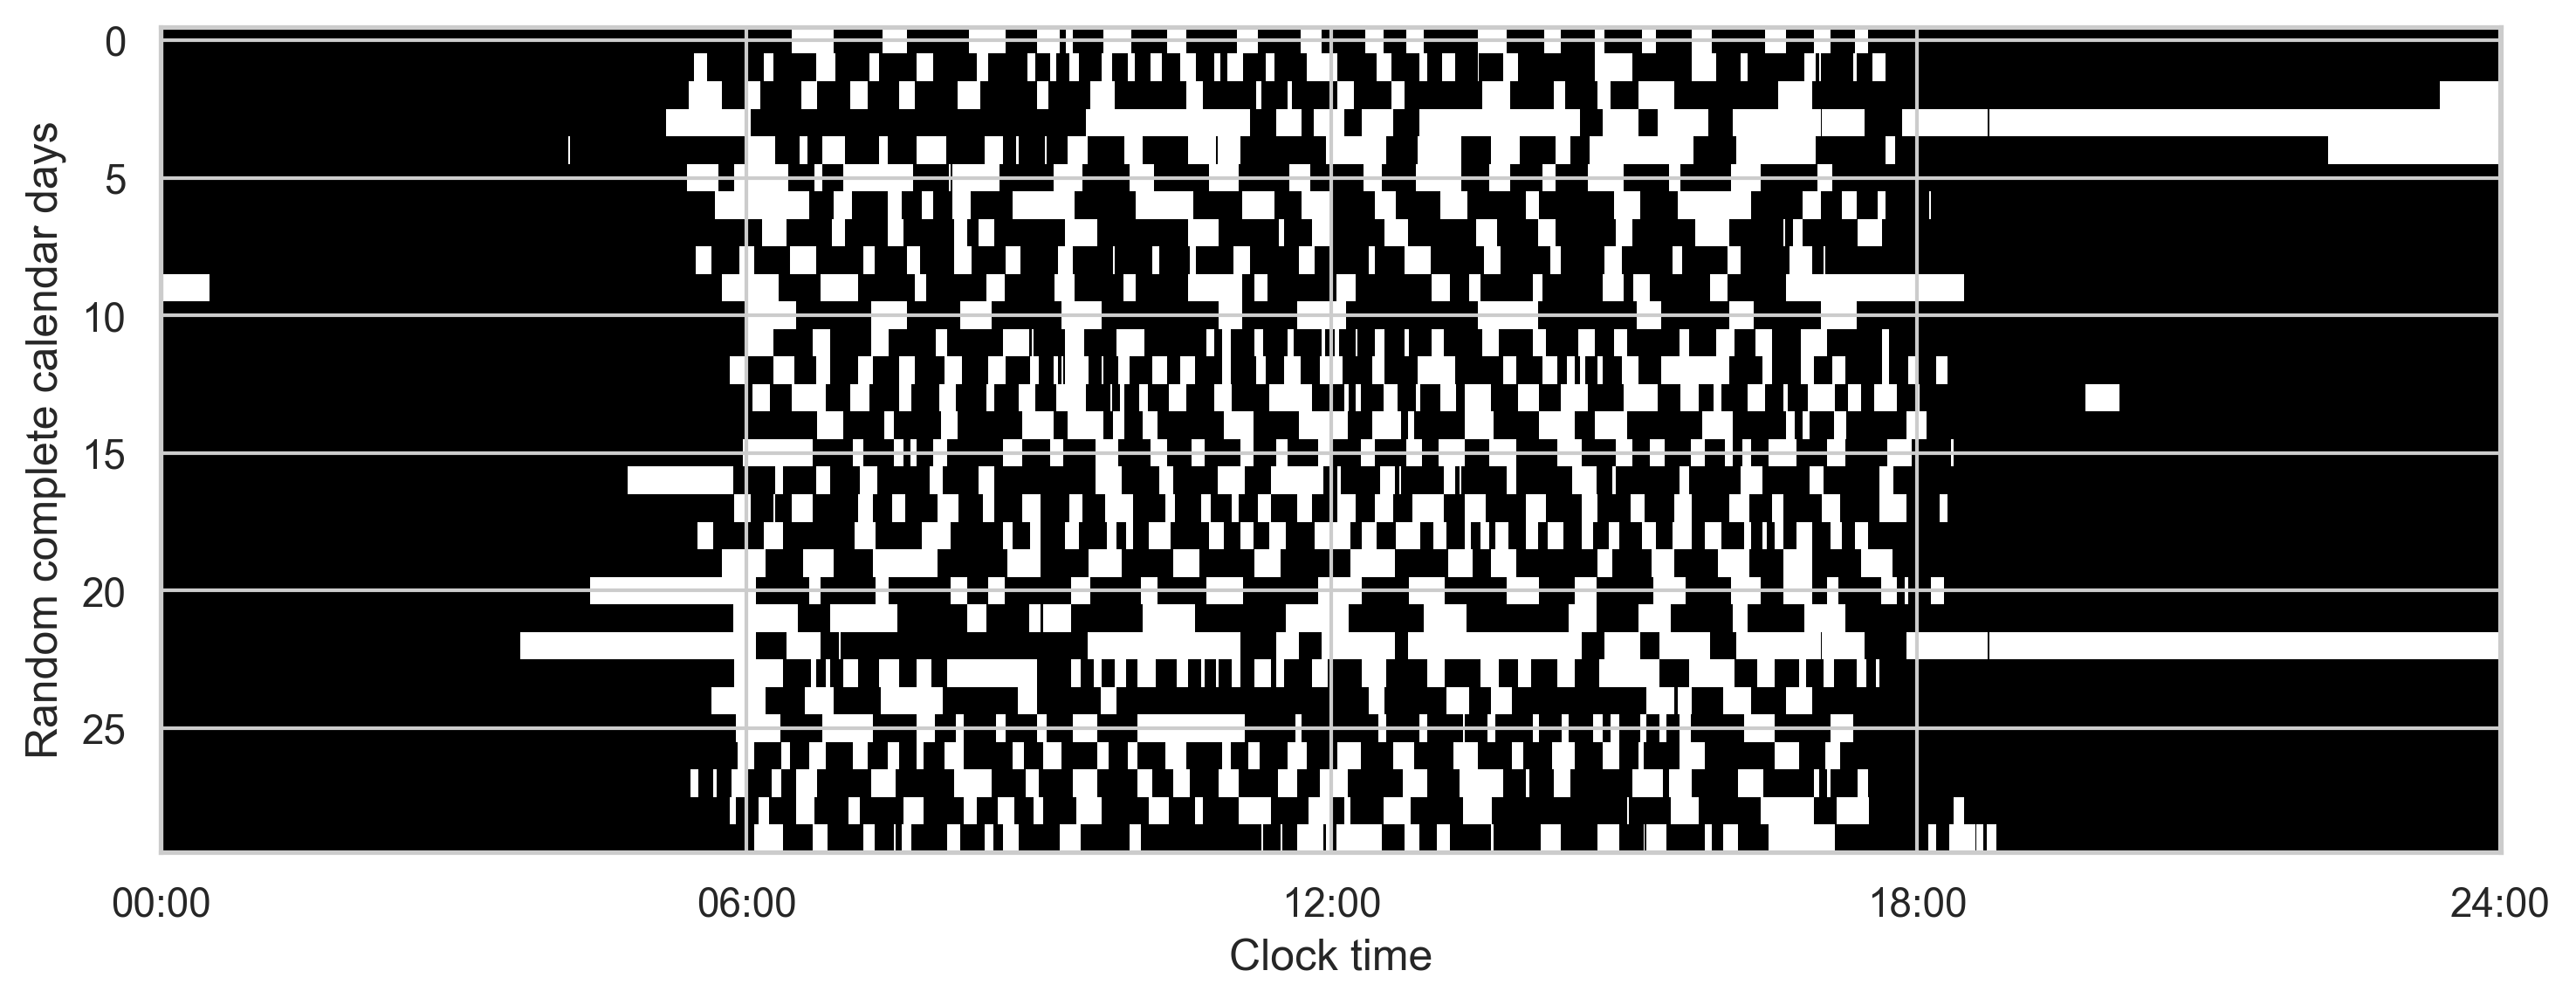

In [749]:
df_raster = df_calendar_complete[[
    "archivo", "calendar_date", "clock_minute", "incubating"
]].copy()

matrix_df = df_raster.pivot(
    index=["archivo", "calendar_date"],
    columns="clock_minute",
    values="incubating"
)

matrix_df = matrix_df.reindex(columns=range(1440)).dropna()

print("Raster matrix shape:", matrix_df.shape)

matrix_df_plot = matrix_df.sample(
    n=min(30, len(matrix_df)),
    random_state=42
)

matrix = matrix_df_plot.to_numpy()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

ax.imshow(
    matrix,
    aspect="auto",
    cmap="binary",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

ax.set_xlabel("Clock time")
ax.set_ylabel("Random complete calendar days")

ax.set_xticks([0, 360, 720, 1080, 1439])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

plt.tight_layout()
plt.show()

In [750]:
# ============================================================
# Sanity check before export
# Are accepted days complete and correctly organised?
# ============================================================

df_check = df_filtrado_completo.copy()

df_check["tiempo"] = pd.to_datetime(df_check["tiempo"], errors="coerce")
df_check["clock_minute"] = df_check["tiempo"].dt.hour * 60 + df_check["tiempo"].dt.minute

# Binary rhythm:
# Nocturnal = 1
# On        = 1
# Off       = 0
df_check["incubating"] = np.where(df_check["prediccion"].isin([0, 2]), 1, 0)

summary_check = (
    df_check
    .groupby(["archivo", "dia"])
    .agg(
        n_rows=("prediccion", "size"),
        n_unique_minuto=("minuto", "nunique"),
        n_unique_clock_minute=("clock_minute", "nunique"),
        first_time=("tiempo", "min"),
        last_time=("tiempo", "max"),
        min_clock=("clock_minute", "min"),
        max_clock=("clock_minute", "max"),
        prop_incubating=("incubating", "mean")
    )
    .reset_index()
)

print(summary_check.head(20))
print("\nDays with != 1440 rows:")
print(summary_check[summary_check["n_rows"] != 1440])

print("\nDays with != 1440 unique clock minutes:")
print(summary_check[summary_check["n_unique_clock_minute"] != 1440])

print("\nIncubation proportion summary:")
print(summary_check["prop_incubating"].describe())

                                              archivo  dia  n_rows  \
0   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0    1440   
1   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    1    1440   
2   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    3    1440   
3   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    4    1440   
4   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    5    1440   
5   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    6    1440   
6   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    7    1440   
7   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    8    1440   
8   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    9    1440   
9   Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...   10    1440   
10   Myioborus_melanocephalus_W1a_JAB08_EGG_processed    0    1440   
11   Myioborus_melanocephalus_W1a_JAB08_EGG_processed    1    1440   
12  Myioborus_melanocephalus_W1a_JAB08_EGG_process...    0    1440   
13  Myioborus_melano

In [751]:
# ============================================================
# Export minute-level predictions for the new GAMM notebook
# This file includes only accepted days from data/testing
# and includes the corrected predictions.
# ============================================================

output_path = r"Myiborus_nests/data/minute_predictions_myioborus_calendar.csv"

df_calendar_complete.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved: {output_path}")
print(df_calendar_complete.shape)
print(df_calendar_complete.columns.tolist())

Saved: data/minute_predictions_myioborus_calendar.csv
(299520, 14)
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating']


In [752]:
df_filtrado_completo

,#,tiempo,egg,ambient,tiempo_min,archivo,dia,minuto,prediccion
0,1,2008-08-14 10:01:00,17.034,14.625,601,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,0,2
1,2,2008-08-14 10:02:00,17.011,14.601,602,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,1,1
2,3,2008-08-14 10:03:00,17.058,14.649,603,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,2,1
3,4,2008-08-14 10:04:00,17.082,14.625,604,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,3,1
4,5,2008-08-14 10:05:00,17.082,14.673,605,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,4,1
...,...,...,...,...,...,...,...,...,...
388795,2877,2015-06-07 10:31:00,22.585,24.171,631,Myoburus_miniatus_TA11a_SF15_processed,1,1435,1
388796,2878,2015-06-07 10:32:00,22.537,24.002,632,Myoburus_miniatus_TA11a_SF15_processed,1,1436,1
388797,2879,2015-06-07 10:33:00,22.465,20.412,633,Myoburus_miniatus_TA11a_SF15_processed,1,1437,1
388798,2880,2015-06-07 10:34:00,22.441,20.793,634,Myoburus_miniatus_TA11a_SF15_processed,1,1438,1


In [753]:
def graficar_dia_aleatorio(df_filtrado_completo):
    archivo = random.choice(df_filtrado_completo['archivo'].unique())
    dias = df_filtrado_completo[df_filtrado_completo['archivo'] == archivo]['dia'].unique()
    dia = random.choice(dias)

    df_dia = df_filtrado_completo[
        (df_filtrado_completo['archivo'] == archivo) &
        (df_filtrado_completo['dia'] == dia)
    ].sort_values('tiempo_min')  # 🚨 ordenar por tiempo real

    colores = {0: '#333E48', 1: '#535AA6', 2: '#E28342'}
    etiquetas = {0: 'Nocturnal', 1: 'Off', 2: 'On'}



    plt.figure(figsize=(18, 5))

    # Línea de fondo de temperatura
    plt.plot(df_dia['tiempo_min'], df_dia['egg'], color='black', alpha=0.3, label='Nest Temp')
    plt.plot(df_dia['tiempo_min'], df_dia['ambient'], color='gray', alpha=0.3, label='Ambient Temp')

    for clase in df_dia['prediccion'].unique():
        mask = df_dia['prediccion'] == clase
        plt.scatter(df_dia.loc[mask, 'tiempo_min'], df_dia.loc[mask, 'egg'],
                    color=colores[clase], label=etiquetas[clase], s=10)

    plt.title(f"{archivo} - Día {dia}")
    plt.xlabel("Minuto del día (desde medianoche)")
    plt.ylabel("Temperatura (°C)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

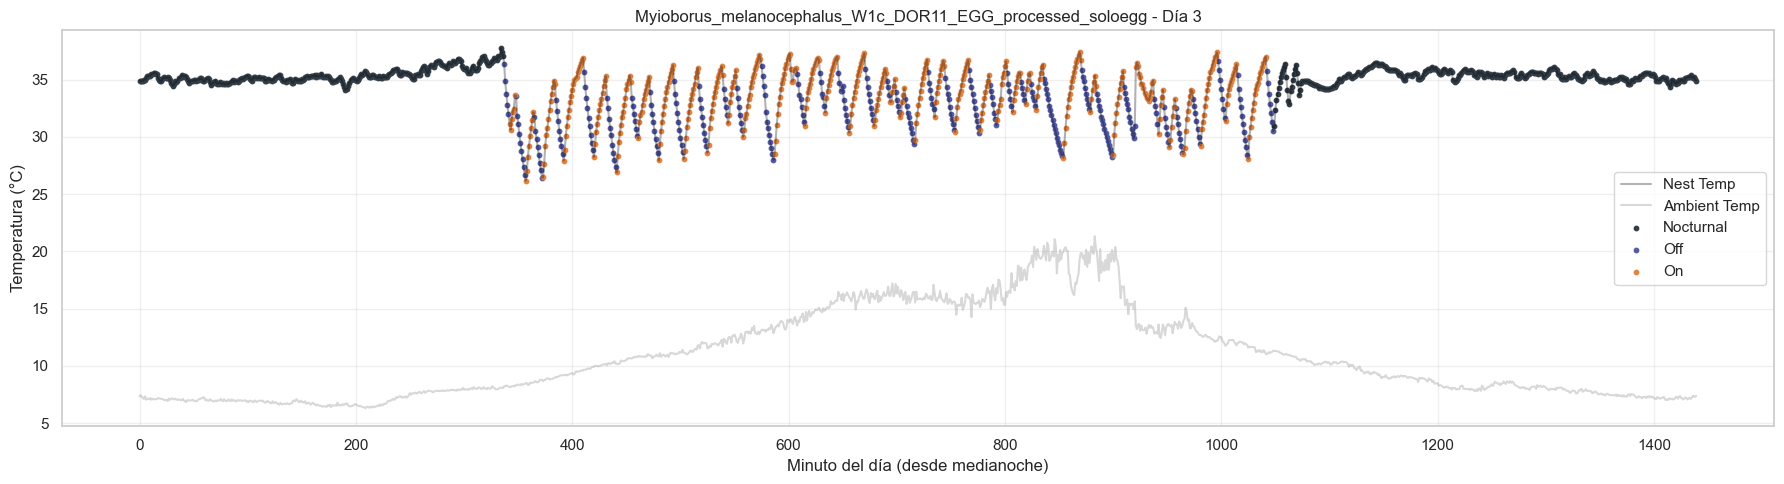

In [754]:
graficar_dia_aleatorio(df_filtrado_completo)

In [755]:
def calcular_estadisticas_generales(grupo):
    return pd.Series({
        'archivo': grupo['archivo'].iloc[0],
        'dia': grupo['dia'].iloc[0],
        'total_on': (grupo['prediccion'] == 2).sum(),
        'total_off': (grupo['prediccion'] == 1).sum(),
        'total_nocturnal': (grupo['prediccion'] == 0).sum(),
        'avg_ambient': grupo['ambient'].mean(),
        'std_ambient': grupo['ambient'].std()
    })


In [756]:
estadisticas_df = df_filtrado_completo.groupby(['archivo', 'dia']).apply(calcular_estadisticas_generales).reset_index(drop=True)
estadisticas_df.to_csv("estadisticas_generales.csv", index=False)

C:\Users\jorge\AppData\Local\Temp\ipykernel_18608\2088123188.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  estadisticas_df = df_filtrado_completo.groupby(['archivo', 'dia']).apply(calcular_estadisticas_generales).reset_index(drop=True)


In [757]:
print(estadisticas_df.head())

                                             archivo  dia  total_on  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0       302   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    1       251   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    3       428   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    4       428   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    5       442   

   total_off  total_nocturnal  avg_ambient  std_ambient  
0        373              765    14.991678     1.451811  
1        403              786    14.515494     1.953879  
2        295              717    15.042069     0.979089  
3        250              762    12.982696     1.235762  
4        231              767    13.744197     0.799791  


In [758]:
def obtener_tipo_sensor(nombre_archivo):
    nombre = nombre_archivo.lower()
    return 'egg' if '_soloegg' in nombre else 'nest'

def extraer_eventos_por_grupo(grupo):
    eventos = []
    evento_id_counter = {'On': 0, 'Off': 0, 'Nocturnal': 0}
    estado_map = {2: 'On', 1: 'Off', 0: 'Nocturnal'}
    archivo_actual = grupo['archivo'].iloc[0]
    sensor = obtener_tipo_sensor(archivo_actual)
    evento_num_total = 1

    i_inicio = 0
    for i in range(1, len(grupo)):
        actual = grupo['prediccion'].iloc[i]
        previo = grupo['prediccion'].iloc[i - 1]

        if actual != previo:
            i_fin = i - 1
            segmento = grupo.iloc[i_inicio:i_fin + 1]
            inicio = segmento.iloc[0]
            fin = segmento.iloc[-1]
            duracion = fin['minuto'] - inicio['minuto'] + 1

            ambient_values = segmento['ambient'].values
            sensor_values = segmento['egg'].values

            # Inicializar campos
            min_temp_off = np.nan
            avg_temp_off = np.nan
            avg_temp_on = np.nan
            avg_ambient_temp_on = np.nan
            avg_temp_nocturnal = np.nan
            avg_ambient_temp_nocturnal = np.nan

            estado_str = estado_map.get(previo, 'Unknown')

            # Reclasificación
            if estado_str == 'Nocturnal' and duracion < 100:
                estado_str = 'On'
                evento_id_counter['On'] += 1
                evento_id_str = f"On_{evento_id_counter['On']}"
                avg_temp_on = np.mean(sensor_values)
                avg_ambient_temp_on = np.mean(ambient_values)
            else:
                evento_id_counter[estado_str] += 1
                evento_id_str = f"{estado_str}_{evento_id_counter[estado_str]}"
                if estado_str == 'Off':
                    min_temp_off = np.min(ambient_values)
                    avg_temp_off = np.mean(sensor_values)
                elif estado_str == 'On':
                    avg_temp_on = np.mean(sensor_values)
                    avg_ambient_temp_on = np.mean(ambient_values)
                elif estado_str == 'Nocturnal':
                    avg_temp_nocturnal = np.mean(sensor_values)
                    avg_ambient_temp_nocturnal = np.mean(ambient_values)

            eventos.append({
                'archivo': inicio['archivo'],
                'dia': inicio['dia'],
                'evento_id': evento_id_str,
                'evento_num': evento_num_total,
                'estado': estado_str,
                'minuto_inicio': inicio['minuto'],
                'minuto_fin': fin['minuto'],
                'tiempo_inicio': inicio['tiempo'],
                'tiempo_fin': fin['tiempo'],
                'duracion_min': duracion,
                'sensor': sensor,
                'min_temp_off': min_temp_off,
                'avg_temp_off': avg_temp_off,
                'avg_temp_on': avg_temp_on,
                'avg_ambient_temp_on': avg_ambient_temp_on,
                'avg_temp_nocturnal': avg_temp_nocturnal,
                'avg_ambient_temp_nocturnal': avg_ambient_temp_nocturnal
            })
            evento_num_total += 1
            i_inicio = i

    # Último segmento
    segmento = grupo.iloc[i_inicio:]
    inicio = segmento.iloc[0]
    fin = segmento.iloc[-1]
    duracion = fin['minuto'] - inicio['minuto'] + 1

    ambient_values = segmento['ambient'].values
    sensor_values = segmento['egg'].values

    min_temp_off = np.nan
    avg_temp_off = np.nan
    avg_temp_on = np.nan
    avg_ambient_temp_on = np.nan
    avg_temp_nocturnal = np.nan
    avg_ambient_temp_nocturnal = np.nan

    estado_str = estado_map.get(grupo['prediccion'].iloc[-1], 'Unknown')

    if estado_str == 'Nocturnal' and duracion < 100:
        estado_str = 'On'
        evento_id_counter['On'] += 1
        evento_id_str = f"On_{evento_id_counter['On']}"
        avg_temp_on = np.mean(sensor_values)
        avg_ambient_temp_on = np.mean(ambient_values)
    else:
        evento_id_counter[estado_str] += 1
        evento_id_str = f"{estado_str}_{evento_id_counter[estado_str]}"
        if estado_str == 'Off':
            min_temp_off = np.min(ambient_values)
            avg_temp_off = np.mean(sensor_values)
        elif estado_str == 'On':
            avg_temp_on = np.mean(sensor_values)
            avg_ambient_temp_on = np.mean(ambient_values)
        elif estado_str == 'Nocturnal':
            avg_temp_nocturnal = np.mean(sensor_values)
            avg_ambient_temp_nocturnal = np.mean(ambient_values)

    eventos.append({
        'archivo': inicio['archivo'],
        'dia': inicio['dia'],
        'evento_id': evento_id_str,
        'evento_num': evento_num_total,
        'estado': estado_str,
        'minuto_inicio': inicio['minuto'],
        'minuto_fin': fin['minuto'],
        'tiempo_inicio': inicio['tiempo'],
        'tiempo_fin': fin['tiempo'],
        'duracion_min': duracion,
        'sensor': sensor,
        'min_temp_off': min_temp_off,
        'avg_temp_off': avg_temp_off,
        'avg_temp_on': avg_temp_on,
        'avg_ambient_temp_on': avg_ambient_temp_on,
        'avg_temp_nocturnal': avg_temp_nocturnal,
        'avg_ambient_temp_nocturnal': avg_ambient_temp_nocturnal
    })

    return eventos

In [759]:
df_filtrado_completo['tiempo'] = pd.to_datetime(df_filtrado_completo['tiempo'])

todos_los_eventos = []
for (archivo, dia), grupo in df_filtrado_completo.groupby(['archivo', 'dia']):
    grupo_ordenado = grupo.sort_values('minuto')
    eventos = extraer_eventos_por_grupo(grupo_ordenado)
    todos_los_eventos.extend(eventos)

eventos_df = pd.DataFrame(todos_los_eventos)

In [760]:
eventos_df

,archivo,dia,evento_id,evento_num,estado,minuto_inicio,minuto_fin,tiempo_inicio,tiempo_fin,duracion_min,sensor,min_temp_off,avg_temp_off,avg_temp_on,avg_ambient_temp_on,avg_temp_nocturnal,avg_ambient_temp_nocturnal
0,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,On_1,1,On,0,0,2008-08-14 10:01:00,2008-08-14 10:01:00,1,nest,NaN,NaN,17.034000,14.625000,NaN,NaN
1,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,Off_1,2,Off,1,62,2008-08-14 10:02:00,2008-08-14 11:03:00,62,nest,14.505,17.353290,NaN,NaN,NaN,NaN
2,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,On_2,3,On,63,66,2008-08-14 11:04:00,2008-08-14 11:07:00,4,nest,NaN,NaN,18.789750,15.610750,NaN,NaN
3,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,Off_2,4,Off,67,67,2008-08-14 11:08:00,2008-08-14 11:08:00,1,nest,15.676,19.222000,NaN,NaN,NaN,NaN
4,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,On_3,5,On,68,74,2008-08-14 11:09:00,2008-08-14 11:15:00,7,nest,NaN,NaN,28.806286,25.032429,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11890,Myoburus_miniatus_TA11a_SF15_processed,1,Off_14,28,Off,1266,1279,2015-06-07 07:42:00,2015-06-07 07:55:00,14,nest,13.978,23.706857,NaN,NaN,NaN,NaN
11891,Myoburus_miniatus_TA11a_SF15_processed,1,On_14,29,On,1280,1301,2015-06-07 07:56:00,2015-06-07 08:17:00,22,nest,NaN,NaN,28.812636,14.602545,NaN,NaN
11892,Myoburus_miniatus_TA11a_SF15_processed,1,Off_15,30,Off,1302,1311,2015-06-07 08:18:00,2015-06-07 08:27:00,10,nest,18.913,25.133000,NaN,NaN,NaN,NaN
11893,Myoburus_miniatus_TA11a_SF15_processed,1,On_15,31,On,1312,1339,2015-06-07 08:28:00,2015-06-07 08:55:00,28,nest,NaN,NaN,36.219964,20.737286,NaN,NaN


In [761]:
print(eventos_df.columns)


Index(['archivo', 'dia', 'evento_id', 'evento_num', 'estado', 'minuto_inicio',
       'minuto_fin', 'tiempo_inicio', 'tiempo_fin', 'duracion_min', 'sensor',
       'min_temp_off', 'avg_temp_off', 'avg_temp_on', 'avg_ambient_temp_on',
       'avg_temp_nocturnal', 'avg_ambient_temp_nocturnal'],
      dtype='object')


In [762]:
# 1. Crear columna auxiliar con el ID base del nido (quitando "_soloegg" y "_processed")
eventos_df['nido_id'] = eventos_df['archivo'].str.replace('_soloegg', '', regex=False).str.replace('_processed', '', regex=False)

# 2. Separar en dos datasets por tipo de sensor
egg_df = eventos_df[eventos_df['sensor'] == 'egg']
nest_df = eventos_df[eventos_df['sensor'] == 'nest']

# 3. Identificar los nido_id que tienen versión tipo "egg"
nidos_con_egg = set(egg_df['nido_id'].unique())

# 4. Filtrar los nidos (sensor nest) que NO tienen equivalente en egg
nest_sin_egg_df = nest_df[~nest_df['nido_id'].isin(nidos_con_egg)]

# 5. Unir los dos subconjuntos: todos los de huevo y los nidos que no están duplicados
eventos_filtrados = pd.concat([egg_df, nest_sin_egg_df], ignore_index=True)

# (opcional) eliminar la columna auxiliar
eventos_filtrados = eventos_filtrados.drop(columns=['nido_id'])


In [763]:
eventos_filtrados

,archivo,dia,evento_id,evento_num,estado,minuto_inicio,minuto_fin,tiempo_inicio,tiempo_fin,duracion_min,sensor,min_temp_off,avg_temp_off,avg_temp_on,avg_ambient_temp_on,avg_temp_nocturnal,avg_ambient_temp_nocturnal
0,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,On_1,1,On,0,0,2008-11-19 08:04:00,2008-11-19 08:04:00,1,egg,NaN,NaN,21.390000,32.665000,NaN,NaN
1,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,Off_1,2,Off,1,12,2008-11-19 08:05:00,2008-11-19 08:16:00,12,egg,12.437,7.305000,NaN,NaN,NaN,NaN
2,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,On_2,3,On,13,19,2008-11-19 08:17:00,2008-11-19 08:23:00,7,egg,NaN,NaN,14.228000,13.462143,NaN,NaN
3,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,Off_2,4,Off,20,69,2008-11-19 08:24:00,2008-11-19 09:13:00,50,egg,13.978,16.349680,NaN,NaN,NaN,NaN
4,Myioborus_melanocephalus_W1a_JAB08_EGG_process...,0,On_3,5,On,70,142,2008-11-19 09:14:00,2008-11-19 10:26:00,73,egg,NaN,NaN,23.947507,14.647425,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,Myoburus_miniatus_TA11a_SF15_processed,1,Off_14,28,Off,1266,1279,2015-06-07 07:42:00,2015-06-07 07:55:00,14,nest,13.978,23.706857,NaN,NaN,NaN,NaN
8946,Myoburus_miniatus_TA11a_SF15_processed,1,On_14,29,On,1280,1301,2015-06-07 07:56:00,2015-06-07 08:17:00,22,nest,NaN,NaN,28.812636,14.602545,NaN,NaN
8947,Myoburus_miniatus_TA11a_SF15_processed,1,Off_15,30,Off,1302,1311,2015-06-07 08:18:00,2015-06-07 08:27:00,10,nest,18.913,25.133000,NaN,NaN,NaN,NaN
8948,Myoburus_miniatus_TA11a_SF15_processed,1,On_15,31,On,1312,1339,2015-06-07 08:28:00,2015-06-07 08:55:00,28,nest,NaN,NaN,36.219964,20.737286,NaN,NaN


In [764]:
def calcular_nest_attentiveness_diurna_con_estadisticas(df_eventos):
    resultados = []

    for (archivo, dia), grupo in df_eventos.groupby(['archivo', 'dia']):
        grupo = grupo.sort_values('minuto_inicio')
        grupo_off = grupo[grupo['estado'] == 'Off']
        grupo_on = grupo[grupo['estado'] == 'On']
        grupo_nocturnal = grupo[grupo['estado'] == 'Nocturnal']

        # Nest attentiveness solo si hay off y nocturnal
        if len(grupo_off) == 0 or len(grupo_nocturnal) == 0:
            resultados.append({
                'archivo': archivo,
                'dia': dia,
                'nest_attentiveness_day': np.nan,
                'duracion_total_on': np.nan,
                'duracion_intervalo_day': np.nan,
                'inicio_intervalo': np.nan,
                'fin_intervalo': np.nan,
                'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
                'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
                'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
                'n_eventos_on': len(grupo_on),
                'n_eventos_off': len(grupo_off)
            })
            continue

        # Intervalo diurno: primer OFF hasta inicio del último NOCTURNAL
        inicio_intervalo = grupo_off['minuto_inicio'].iloc[0]
        fin_intervalo = grupo_nocturnal['minuto_inicio'].iloc[-1] - 1
        duracion_intervalo = fin_intervalo - inicio_intervalo + 1

        if duracion_intervalo <= 0:
            resultados.append({
                'archivo': archivo,
                'dia': dia,
                'nest_attentiveness_day': np.nan,
                'duracion_total_on': 0,
                'duracion_intervalo_day': duracion_intervalo,
                'inicio_intervalo': inicio_intervalo,
                'fin_intervalo': fin_intervalo,
                'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
                'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
                'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
                'n_eventos_on': len(grupo_on),
                'n_eventos_off': len(grupo_off)
            })
            continue

        grupo_on_filtrado = grupo_on[
            (grupo_on['minuto_inicio'] >= inicio_intervalo) &
            (grupo_on['minuto_fin'] <= fin_intervalo)
        ]

        duracion_total_on = grupo_on_filtrado['duracion_min'].sum()
        nest_attentiveness = duracion_total_on / duracion_intervalo

        resultados.append({
            'archivo': archivo,
            'dia': dia,
            'nest_attentiveness_day': nest_attentiveness,
            'duracion_total_on': duracion_total_on,
            'duracion_intervalo_day': duracion_intervalo,
            'inicio_intervalo': inicio_intervalo,
            'fin_intervalo': fin_intervalo,
            'avg_duracion_on': grupo_on['duracion_min'].mean() if len(grupo_on) > 0 else np.nan,
            'avg_duracion_off': grupo_off['duracion_min'].mean() if len(grupo_off) > 0 else np.nan,
            'avg_duracion_nocturnal': grupo_nocturnal['duracion_min'].mean() if len(grupo_nocturnal) > 0 else np.nan,
            'n_eventos_on': len(grupo_on),
            'n_eventos_off': len(grupo_off)
        })

    return pd.DataFrame(resultados)

In [765]:
nest_attentiveness_day_df = calcular_nest_attentiveness_diurna_con_estadisticas(eventos_filtrados)


In [766]:
nest_attentiveness_day_df


,archivo,dia,nest_attentiveness_day,duracion_total_on,duracion_intervalo_day,inicio_intervalo,fin_intervalo,avg_duracion_on,avg_duracion_off,avg_duracion_nocturnal,n_eventos_on,n_eventos_off
0,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,0.415677,175.0,421.0,1.0,421.0,25.166667,28.692308,765.0,12,13
1,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,1,0.156182,144.0,922.0,1.0,922.0,20.916667,28.785714,393.0,12,14
2,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,3,0.635036,261.0,411.0,6.0,416.0,21.400000,15.526316,717.0,20,19
3,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,4,0.617925,262.0,424.0,20.0,443.0,22.400000,11.904762,742.0,20,21
4,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,5,0.676674,293.0,433.0,1.0,433.0,19.217391,10.043478,767.0,23,23
...,...,...,...,...,...,...,...,...,...,...,...,...
196,Myoborus_ornatus_TA37a_ROAD15_processed,3,0.423381,268.0,633.0,0.0,632.0,19.714286,38.333333,589.0,14,15
197,Myoborus_ornatus_TA3Xa_ROAD15_processed,1,0.404478,271.0,670.0,0.0,669.0,70.700000,47.000000,263.0,10,10
198,Myoborus_ornatus_TA3Xa_ROAD15_processed,3,0.343112,269.0,784.0,0.0,783.0,20.846154,41.428571,589.0,13,14
199,Myoburus_miniatus_TA11a_SF15_processed,0,0.641425,288.0,449.0,1.0,449.0,35.214286,16.133333,705.0,14,15


In [767]:
promedios_ambient = df_filtrado_completo.groupby(['archivo', 'dia'])['ambient'].mean().reset_index()
promedios_ambient = promedios_ambient.rename(columns={'ambient': 'avg_temp_ambient_diaria'})

In [768]:
# Unir por archivo y dia
nest_attentiveness_day_df = nest_attentiveness_day_df.merge(
    promedios_ambient,
    on=['archivo', 'dia'],
    how='left'
)


In [769]:
nest_attentiveness_day_df


,archivo,dia,nest_attentiveness_day,duracion_total_on,duracion_intervalo_day,inicio_intervalo,fin_intervalo,avg_duracion_on,avg_duracion_off,avg_duracion_nocturnal,n_eventos_on,n_eventos_off,avg_temp_ambient_diaria
0,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,0.415677,175.0,421.0,1.0,421.0,25.166667,28.692308,765.0,12,13,14.991678
1,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,1,0.156182,144.0,922.0,1.0,922.0,20.916667,28.785714,393.0,12,14,14.515494
2,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,3,0.635036,261.0,411.0,6.0,416.0,21.400000,15.526316,717.0,20,19,15.042069
3,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,4,0.617925,262.0,424.0,20.0,443.0,22.400000,11.904762,742.0,20,21,12.982696
4,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,5,0.676674,293.0,433.0,1.0,433.0,19.217391,10.043478,767.0,23,23,13.744197
...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,Myoborus_ornatus_TA37a_ROAD15_processed,3,0.423381,268.0,633.0,0.0,632.0,19.714286,38.333333,589.0,14,15,14.729694
197,Myoborus_ornatus_TA3Xa_ROAD15_processed,1,0.404478,271.0,670.0,0.0,669.0,70.700000,47.000000,263.0,10,10,15.729102
198,Myoborus_ornatus_TA3Xa_ROAD15_processed,3,0.343112,269.0,784.0,0.0,783.0,20.846154,41.428571,589.0,13,14,14.737769
199,Myoburus_miniatus_TA11a_SF15_processed,0,0.641425,288.0,449.0,1.0,449.0,35.214286,16.133333,705.0,14,15,19.322328


In [770]:
nest_attentiveness_day_df = nest_attentiveness_day_df.dropna(subset=['nest_attentiveness_day']).reset_index(drop=True)

In [771]:
nest_attentiveness_day_df = nest_attentiveness_day_df[
    (nest_attentiveness_day_df['nest_attentiveness_day'].notna()) &
    (nest_attentiveness_day_df['nest_attentiveness_day'] > 0)
].reset_index(drop=True)

In [772]:
import sys
print(sys.executable)

D:\Myiborus\.venv\Scripts\python.exe


In [773]:
# Cargar el archivo de morfología
ruta_morfologia = 'data\Datos morfológicos_Nidos_Myioborus.xlsx'
df_morfologia = pd.read_excel(ruta_morfologia)

df_morfologia

,Estacion,Numero_Libreta,Pagina,Año,Familia,Especie,ID_del_Nido,S,W,Elevacion,...,Fecha_puesta_2dohuevo,Fecha_eclosion_1rhuevo,Fecha_eclosion_2dohuevo,Fecha_salida_1rpolluelo,Fecha_salida_2dopolluelo,Notas.1,Fecha_Depredado,Depredador,Fecha.Final.Camara.trampa,Fecha.final.Data.logger
0,Chicoral,1,3,2015,Parulidae,Myioborus_miniatus,CH03_ACC15,NaN,76.5833,2034.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Chicoral,1,31,2015,Parulidae,Myioborus_miniatus,CH06_AMM15,NaN,76.5836,2040.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Chicoral,1,31,2015,Parulidae,Myioborus_miniatus,CH06_AMM15,NaN,76.5836,2040.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chicoral,1,31,2015,Parulidae,Myioborus_miniatus,CH06_AMM15,NaN,76.5836,2040.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Chicoral,1,31,2015,Parulidae,Myioborus_miniatus,CH06_AMM15,NaN,76.5836,2040.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,Zygia,2,156,2015,Parulidae,Myioborus_miniatus,FA17_MAL15,NaN,76.6643,2324.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
752,Zygia,3,86,2015,Parulidae,Myioborus_miniatus,FA08_MAL15,NaN,76.6663,2289.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
753,Zygia,3,86,2015,Parulidae,Myioborus_miniatus,FA08_MAL15,NaN,76.6663,2289.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
754,Zygia,NaN,64,2018,Parulidae,Myioborus_miniatus,FA04_MMC18,NaN,NaN,2242.661538,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [774]:
print(df_morfologia.columns.tolist())

['Estacion', 'Numero_Libreta', 'Pagina', 'Año', 'Familia', 'Especie', 'ID_del_Nido', 'S', 'W', 'Elevacion', 'Fecha_de_encuentro', 'Fecha _eclosion', 'Ultima_fecha_de_actividad', 'Fecha_de_inactividad (Last day nest was checked)', 'Dias_Totales', 'Estado', 'Notas', 'Huevo_o_Polluelo', 'Tipo_de_nido', 'Nido_Int_Largo_mm', 'Nido_Int_Ancho_mm', 'Nido_Int_Espesor_mm', 'Nido_Int_Profundidad_1_mm', 'Nido_Int_Profundidad_2_mm', 'Nido_Ext_Largo_mm', 'Nido_Ext_Ancho_mm', 'Nido_Ext_Alto_mm', 'Altura_sobre_el_suelo_cm', 'Nido_peso_Total_g', 'Capa_1_g', 'Capa_2_g', 'Capa_3_g', 'Capa_4_g', 'Material_extra_g', 'ID_del_Huevo', 'Desarrollo huevos', 'Huevo_Largo_mm', 'Huevo_Ancho_mm', 'Huevo_Peso_g', 'Medianas y desviacion 95%', 'Numero_de_Huevos', 'Fecha_de_medición', 'ID_del_Polluelo', 'Individuo', 'Polluelo_Edad_dias', 'Polluelo_Masa_g', 'Polluelo_Tarso_mm', 'Polluelo_Ala_mm', 'Polluelo_Pico_mm', 'Polluelo_Cola_mm', 'Temp_inicial', 'Temp_final', 'Temp_ambiente', 'Todos_los_huevos_eclosionaron', 'Todo

In [775]:
equivalencias = pd.read_csv("Myiborus_nests/data/resumen_equivalente.csv")
equivalencias

,archivo,equivalente
0,SP12a_RVA10,SP12_RVA10
1,SP12b_RVA10,SP12_RVA10
2,SP12c_RVA10,SP12_RVA10
3,SP1_DAR11,SP1_DAR11
4,SP1_EJWc11,SP1_EJW11
5,SP1b_MCE08,SP1_MCE08
6,SP1d_EJW11,SP1_EJW11
7,SP2a_DOR09,SP2_DOR09
8,SP2b_DOR09,SP2_DOR09
9,SPR01_JCB09,SP1_JCB09


In [776]:
# Hacer una copia
resumen_copy = nest_attentiveness_day_df.copy()

# Agregar columna nido_id extraída del nombre del archivo
def extraer_id_nido(nombre_archivo):
    try:
        partes = nombre_archivo.split("_")
        return "_".join(partes[2:4])  # Ejemplo: TU1a_DOR08
    except:
        return None

resumen_copy['nido_id'] = resumen_copy['archivo'].apply(extraer_id_nido)


In [777]:
resumen_copy

,archivo,dia,nest_attentiveness_day,duracion_total_on,duracion_intervalo_day,inicio_intervalo,fin_intervalo,avg_duracion_on,avg_duracion_off,avg_duracion_nocturnal,n_eventos_on,n_eventos_off,avg_temp_ambient_diaria,nido_id
0,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,0,0.415677,175.0,421.0,1.0,421.0,25.166667,28.692308,765.0,12,13,14.991678,TU1a_DOR08
1,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,1,0.156182,144.0,922.0,1.0,922.0,20.916667,28.785714,393.0,12,14,14.515494,TU1a_DOR08
2,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,3,0.635036,261.0,411.0,6.0,416.0,21.400000,15.526316,717.0,20,19,15.042069,TU1a_DOR08
3,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,4,0.617925,262.0,424.0,20.0,443.0,22.400000,11.904762,742.0,20,21,12.982696,TU1a_DOR08
4,Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...,5,0.676674,293.0,433.0,1.0,433.0,19.217391,10.043478,767.0,23,23,13.744197,TU1a_DOR08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,Myoborus_ornatus_TA37a_ROAD15_processed,3,0.423381,268.0,633.0,0.0,632.0,19.714286,38.333333,589.0,14,15,14.729694,TA37a_ROAD15
180,Myoborus_ornatus_TA3Xa_ROAD15_processed,1,0.404478,271.0,670.0,0.0,669.0,70.700000,47.000000,263.0,10,10,15.729102,TA3Xa_ROAD15
181,Myoborus_ornatus_TA3Xa_ROAD15_processed,3,0.343112,269.0,784.0,0.0,783.0,20.846154,41.428571,589.0,13,14,14.737769,TA3Xa_ROAD15
182,Myoburus_miniatus_TA11a_SF15_processed,0,0.641425,288.0,449.0,1.0,449.0,35.214286,16.133333,705.0,14,15,19.322328,TA11a_SF15


In [778]:
print(resumen_copy[['archivo', 'nido_id']].head(3))
print("IDs nulos:", resumen_copy['nido_id'].isna().sum())

                                             archivo     nido_id
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  TU1a_DOR08
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  TU1a_DOR08
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  TU1a_DOR08
IDs nulos: 0


In [779]:
# Asegurar prevee bro
resumen_copy['nido_id'] = resumen_copy['nido_id'].astype(str).str.strip()
equivalencias['archivo'] = equivalencias['archivo'].astype(str).str.strip()
equivalencias['equivalente'] = equivalencias['equivalente'].astype(str).str.strip()

# Crear diccionario de equivalencias
dict_equiv = dict(zip(equivalencias['archivo'], equivalencias['equivalente']))

# Aplicar las equivalencias
resumen_copy['equivalente'] = resumen_copy['nido_id'].apply(lambda x: dict_equiv.get(x, x))

In [780]:
ids_no_encontrados = resumen_copy[
    ~resumen_copy['nido_id'].isin(equivalencias['archivo'])
]['nido_id'].unique()

print("IDs no encontrados en equivalencias:")
print(ids_no_encontrados)
print("Total:", len(ids_no_encontrados))

IDs no encontrados en equivalencias:
[]
Total: 0


In [781]:
columnas_morfologia = [
    'ID_del_Nido', 'Estacion', 'Especie', 'Familia',
    'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g','Altura_sobre_el_suelo_cm'
]

df_morfologia_filtrado = df_morfologia[columnas_morfologia].copy()

In [782]:
# Limpiar claves
resumen_copy['equivalente'] = resumen_copy['equivalente'].astype(str).str.strip()
df_morfologia_filtrado['ID_del_Nido'] = df_morfologia_filtrado['ID_del_Nido'].astype(str).str.strip()

# Filtrar el DataFrame de morfología para conservar solo una fila con datos de Huevo_Peso_g si existen
df_morfologia_filtrado = (
    df_morfologia_filtrado
    .sort_values(by='Huevo_Peso_g', na_position='last')  # ordenar para que los NaN queden al final
    .drop_duplicates(subset='ID_del_Nido', keep='first')  # quedarte con la fila más completa
)

# Hacer el merge como siempre
resumen_merge = resumen_copy.merge(
    df_morfologia_filtrado,
    left_on='equivalente',
    right_on='ID_del_Nido',
    how='left'
) #### AAAAAQUIIIIIIé

In [783]:
print(resumen_merge.columns.tolist())

['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm']


In [784]:
resumen_merge.to_csv(
    r"D:\Myiborus\data\daily_summary_myioborus.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved daily summary")
print(resumen_merge.shape)
print(resumen_merge.columns.tolist())

Saved daily summary
(184, 25)
['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm']


In [785]:
resumen_merge.to_csv('data/myio_exportado.csv', index=False, encoding='utf-8-sig')

In [786]:
import seaborn as sns

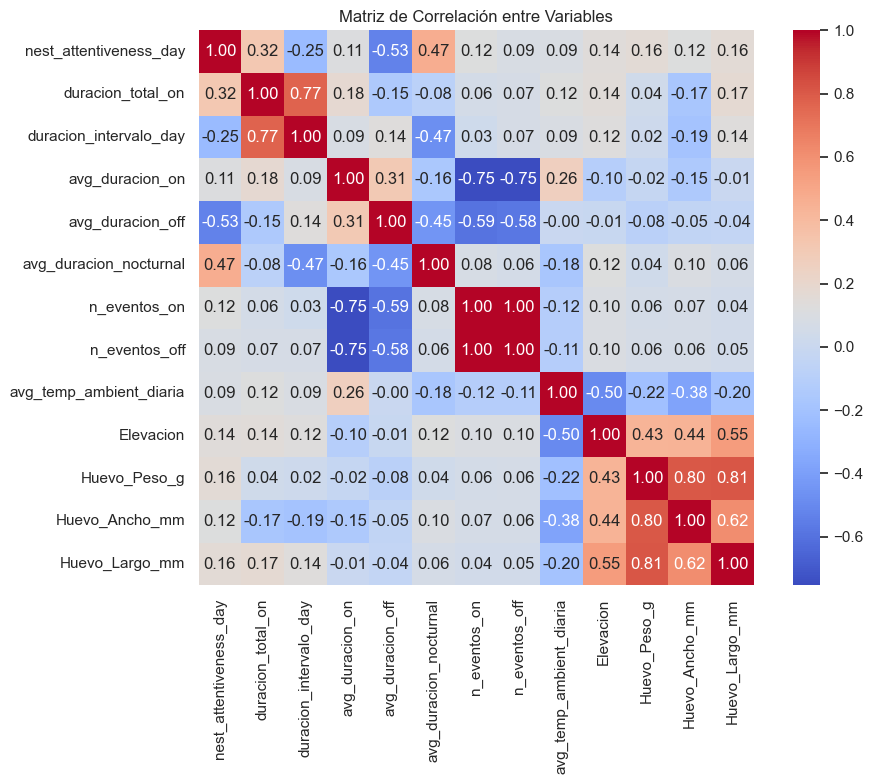

In [787]:
columnas_interes = [
'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm'
]

# Eliminar filas con valores nulos en las columnas de interés
df_corr = resumen_merge[columnas_interes].dropna()

# Calcular matriz de correlación
corr_matrix = df_corr.corr()

# Visualizar con heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Matriz de Correlación entre Variables')
plt.tight_layout()
plt.show()

In [788]:
estadisticas_altura = resumen_merge.groupby('Especie')['Elevacion'].agg(
    Promedio_Elevacion='mean',
    Desviacion_Estandar_Elevacion='std',
    N='count'
).reset_index()

print(estadisticas_altura)

                    Especie  Promedio_Elevacion  \
0  Myioborus_melanocephalus          2649.69246   
1        Myioborus_miniatus          1700.08699   
2         Myioborus_ornatus          2459.75000   

   Desviacion_Estandar_Elevacion    N  
0                     248.337825   36  
1                     400.614032  140  
2                      32.866614    8  


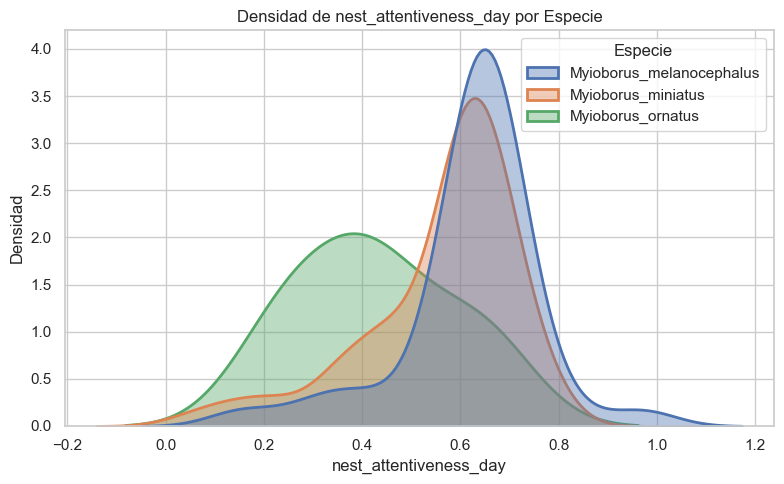

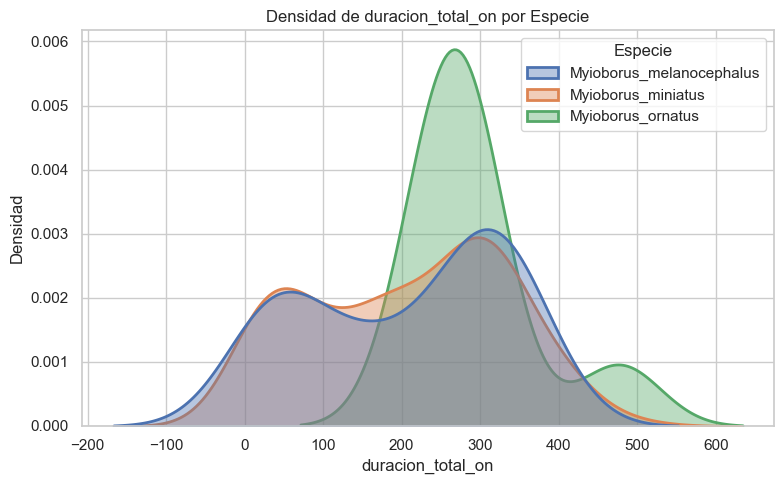

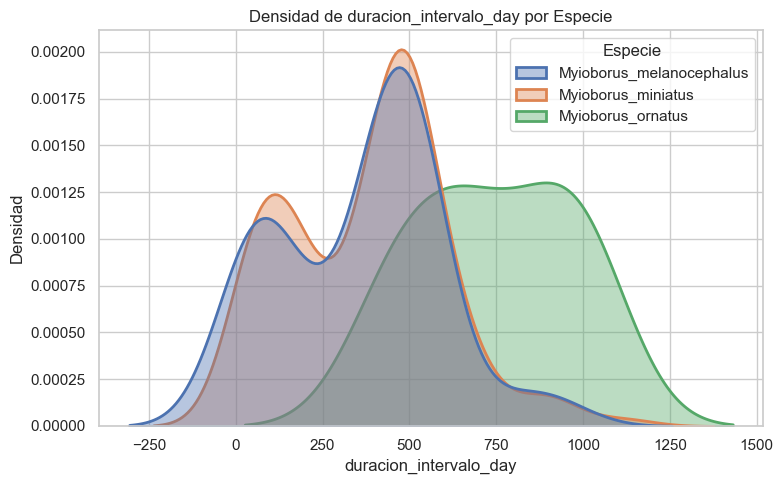

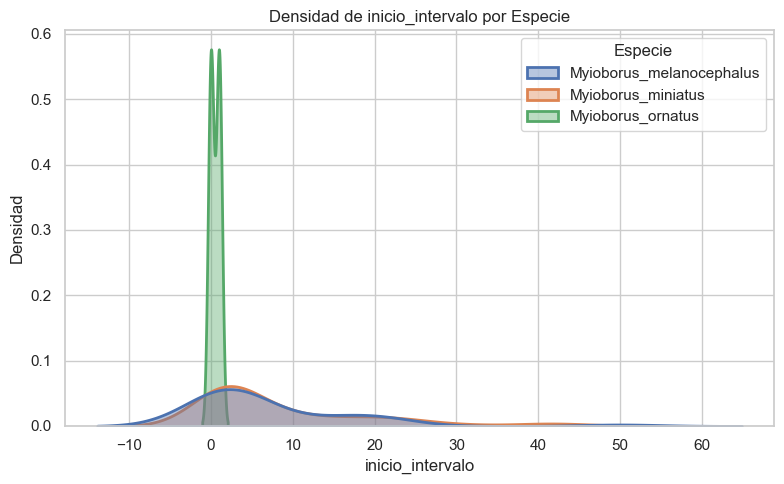

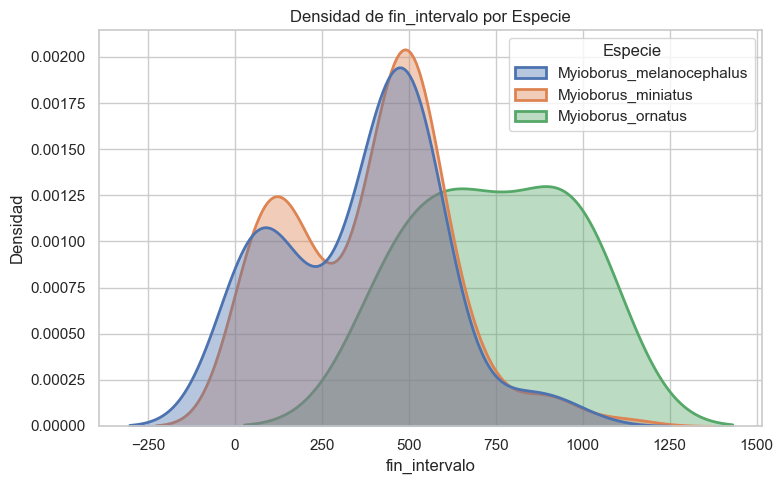

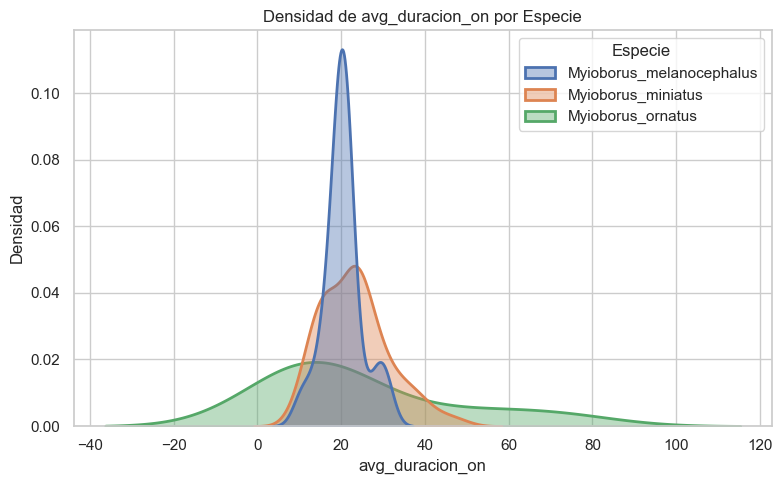

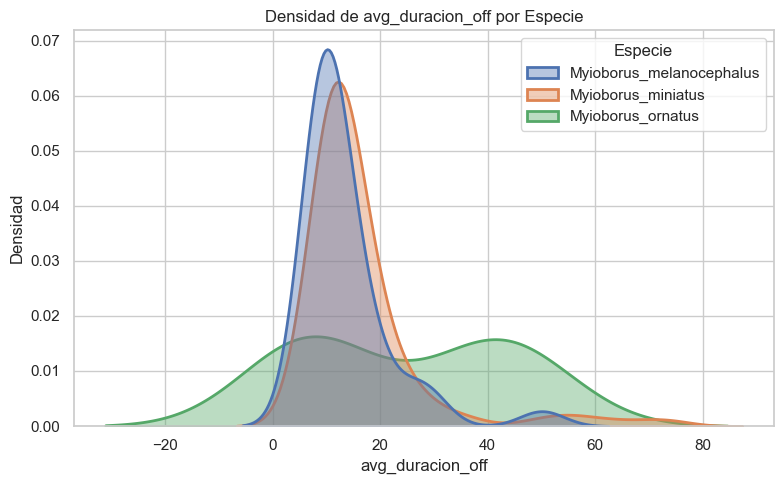

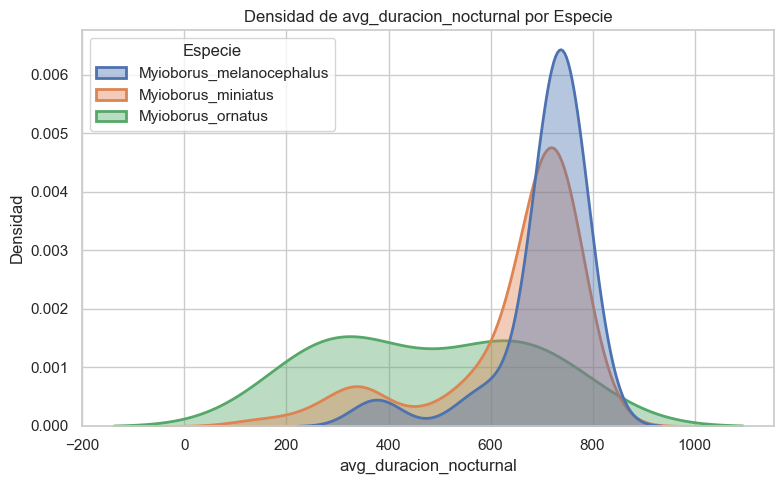

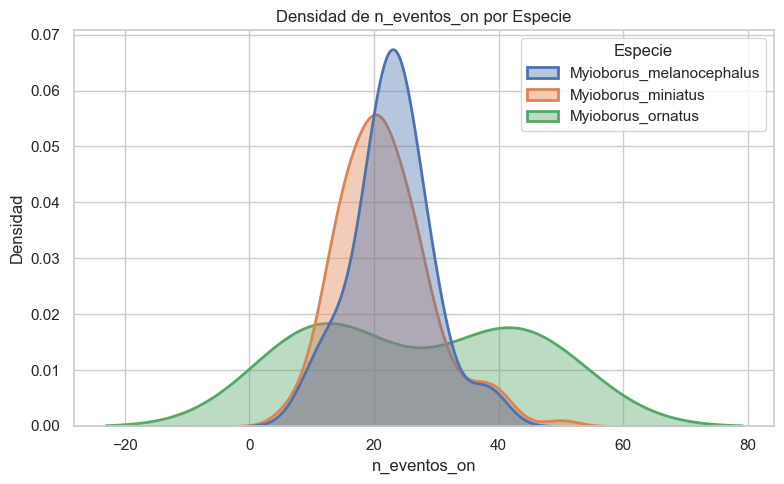

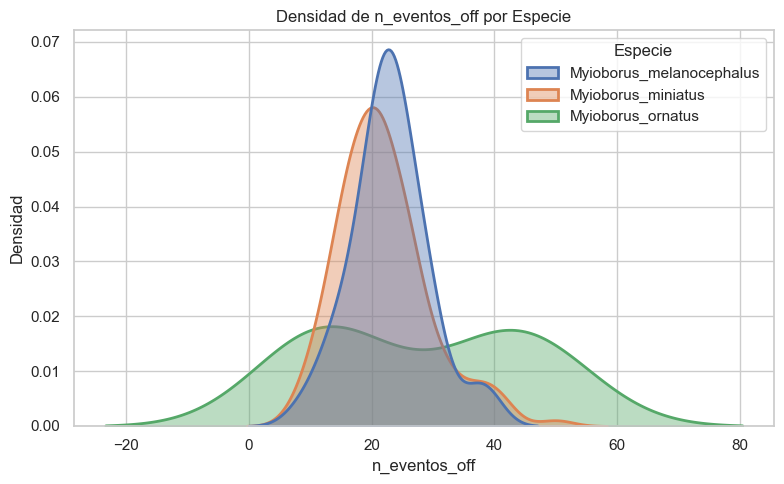

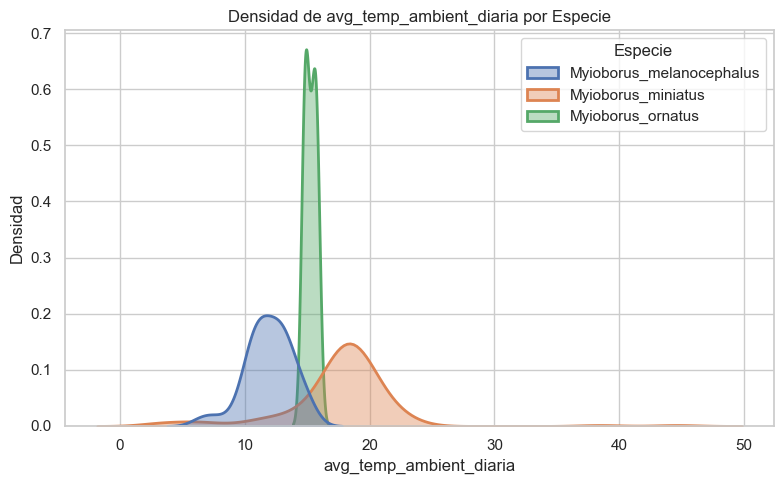

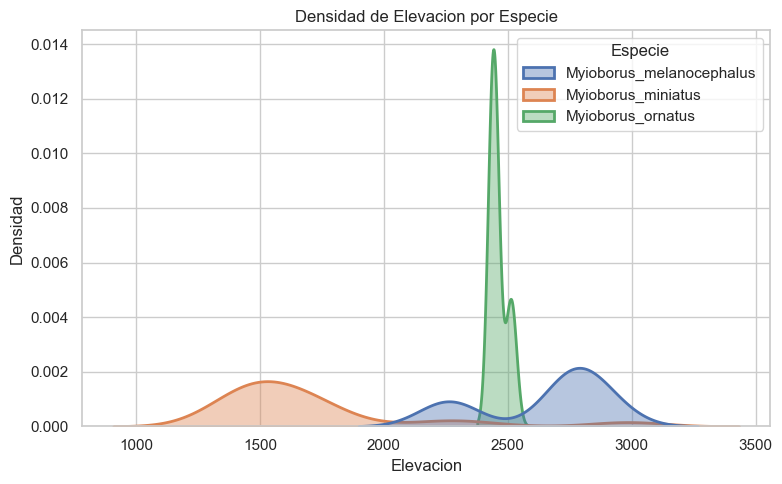

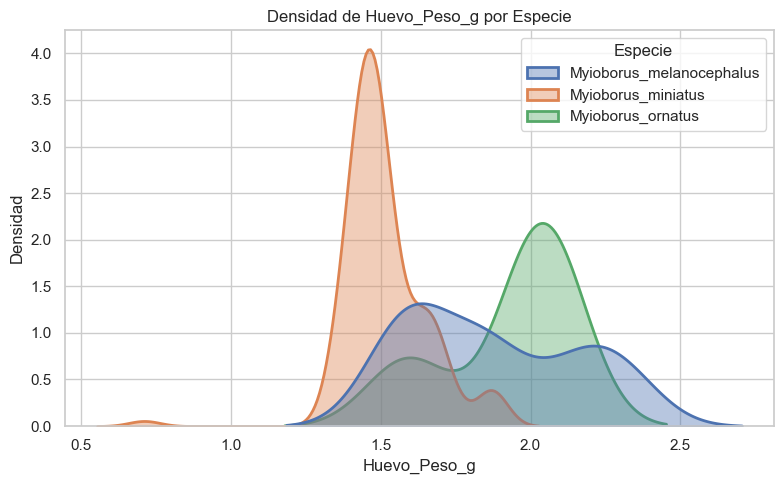

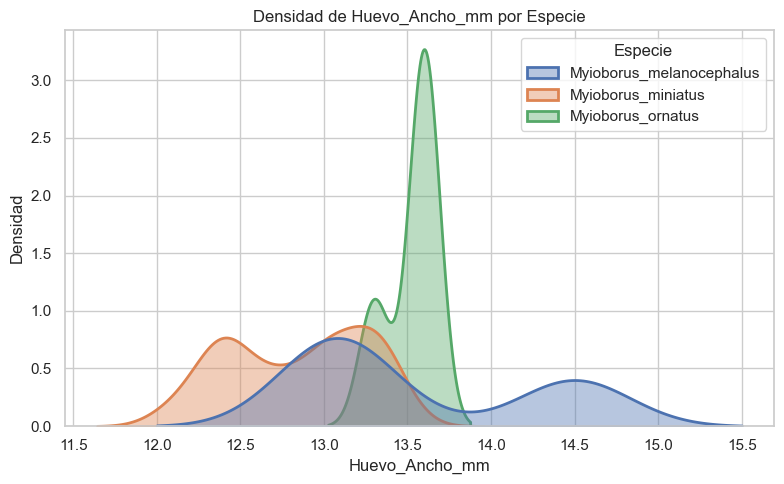

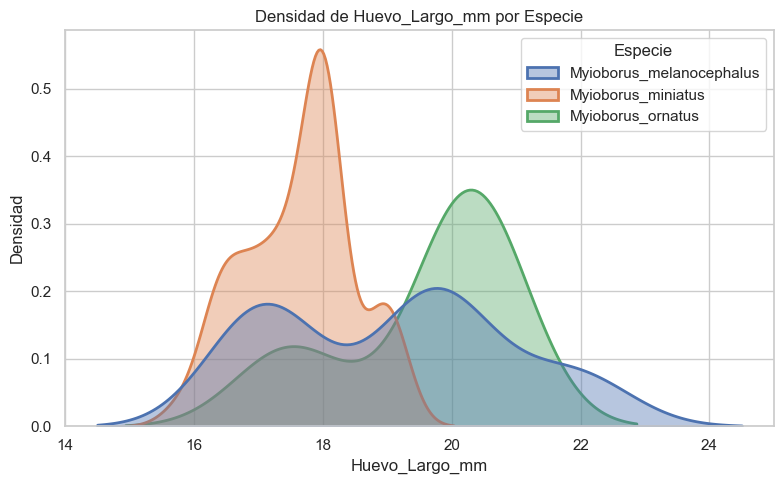

In [789]:
# Variables numéricas a graficar
variables = [
   'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm'
]

# Ajustes generales
sns.set(style="whitegrid")

# Crear una curva de densidad por variable
for var in variables:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(
        data=resumen_merge,
        x=var,
        hue='Especie',
        fill=True,  # Rellenar debajo de la curva
        common_norm=False,  # Normalización separada por especie
        alpha=0.4,  # Transparencia
        linewidth=2
    )
    plt.title(f'Densidad de {var} por Especie')
    plt.xlabel(var)
    plt.ylabel('Densidad')
    plt.tight_layout()
    plt.show()

# Deeping into Miyoborus

In [790]:
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [791]:
#resumen_merge = resumen_merge[resumen_merge['Especie'] != 'Myioborus_ornatus'].copy()
#resumen_merge

In [792]:
columnas_a_revisar = ['nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm']

# Filtrar filas con al menos un NaN en las columnas especificadas
nas_en_columnas = resumen_merge[resumen_merge[columnas_a_revisar].isna().any(axis=1)]

# Mostrar las filas con el ID correspondiente
resultado = nas_en_columnas[['equivalente'] + columnas_a_revisar]
print(resultado)

Empty DataFrame
Columns: [equivalente, nest_attentiveness_day, duracion_total_on, duracion_intervalo_day, avg_duracion_on, avg_duracion_off, avg_duracion_nocturnal, n_eventos_on, n_eventos_off, avg_temp_ambient_diaria, Elevacion, Huevo_Peso_g, Huevo_Ancho_mm, Huevo_Largo_mm]
Index: []


In [793]:
columnas_pca = [
    'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'avg_temp_ambient_diaria', 'Elevacion', 'Huevo_Peso_g'
]

In [794]:
df_pca = resumen_merge[columnas_pca].dropna()
X_scaled = StandardScaler().fit_transform(df_pca)

In [795]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_
var_cumsum = np.cumsum(var_exp)

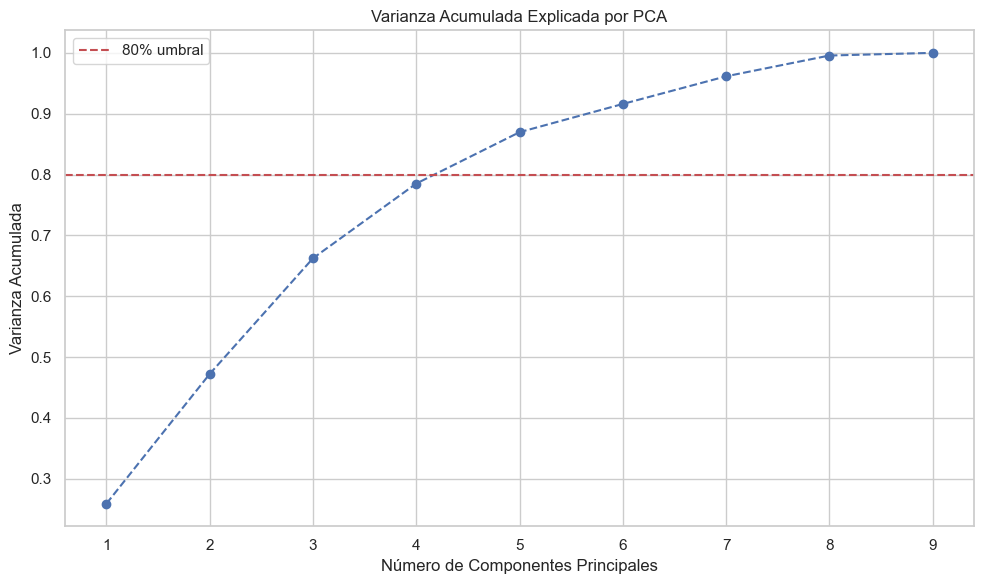

In [796]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(var_exp) + 1), var_cumsum, marker='o', linestyle='--')
plt.title('Varianza Acumulada Explicada por PCA')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
plt.axhline(0.80, color='r', linestyle='--', label='80% umbral')
plt.legend()
plt.tight_layout()
plt.show()

In [797]:
df_pca = resumen_merge.dropna(subset=columnas_pca + ['Especie']).copy()


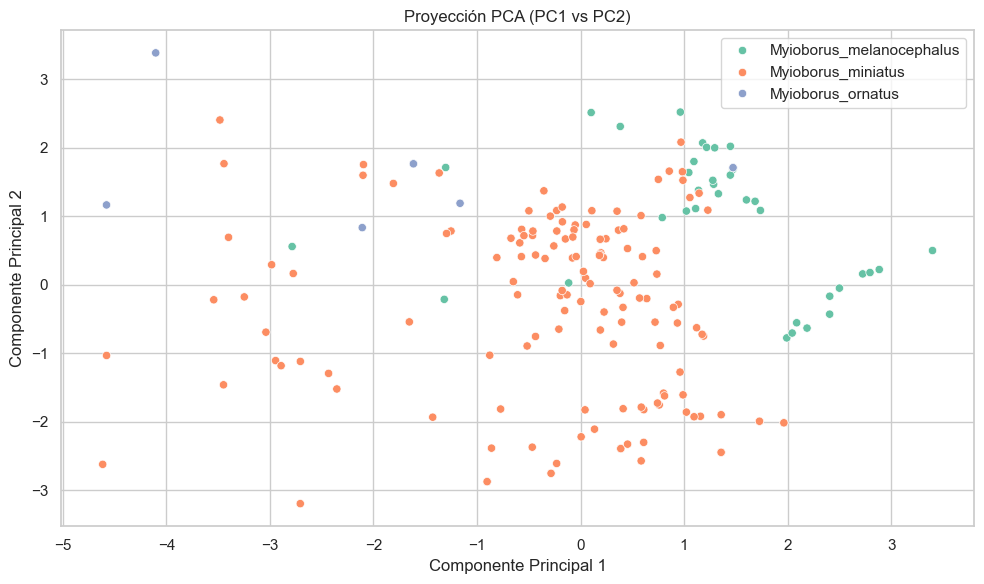

In [798]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# 4. Construir un nuevo DataFrame con los resultados
df_pca_resultado = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
df_pca_resultado['Especie'] = df_pca['Especie'].values

# 5. Visualizar PC1 vs PC2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_pca_resultado, x='PC1', y='PC2', hue='Especie', palette='Set2')
plt.title('Proyección PCA (PC1 vs PC2)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.tight_layout()
plt.show()

In [799]:
pca_final = PCA(n_components=5)
X_pca_final = pca_final.fit_transform(X_scaled)
features = columnas_pca  # Tu lista original de variables usadas en el PCA

loadings = pd.DataFrame(
    pca.components_[:5].T,  # Solo las 5 primeras componentes
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    index=features
)

print(loadings)

                              PC1       PC2       PC3       PC4       PC5
nest_attentiveness_day   0.404207  0.268747  0.394697  0.246179 -0.031768
duracion_total_on       -0.147728  0.626827  0.246455 -0.137051 -0.189276
duracion_intervalo_day  -0.400902  0.507723 -0.021101 -0.288008 -0.016314
avg_duracion_on         -0.243229  0.082040  0.237003  0.741600 -0.265727
avg_duracion_off        -0.430942 -0.164663 -0.304582  0.350340 -0.228719
avg_duracion_nocturnal   0.522383 -0.038446  0.153975  0.023065 -0.342584
avg_temp_ambient_diaria -0.238013 -0.085809  0.554431  0.081457  0.442755
Elevacion                0.207937  0.382749 -0.455835  0.166696 -0.169256
Huevo_Peso_g             0.190858  0.296476 -0.308547  0.360557  0.705644


In [800]:
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.2%} d varianze")

PC1: 25.92% d varianze
PC2: 21.32% d varianze
PC3: 19.01% d varianze
PC4: 12.28% d varianze
PC5: 8.44% d varianze


In [801]:
range_n_clusters = range(2, 11)
n_iter = 10  # número de random_state diferentes para promediar
silhouette_avg = []
inertia_avg = []

for k in range_n_clusters:
    silhouette_k = []
    inertia_k = []

    for seed in range(n_iter):
        kmeans = KMeans(n_clusters=k, random_state=seed, n_init=30)
        labels = kmeans.fit_predict(X_pca)
        silhouette_k.append(silhouette_score(X_pca, labels))
        inertia_k.append(kmeans.inertia_)

    silhouette_avg.append(np.mean(silhouette_k))
    inertia_avg.append(np.mean(inertia_k))


Text(0.5, 1.0, 'Método del Codo')

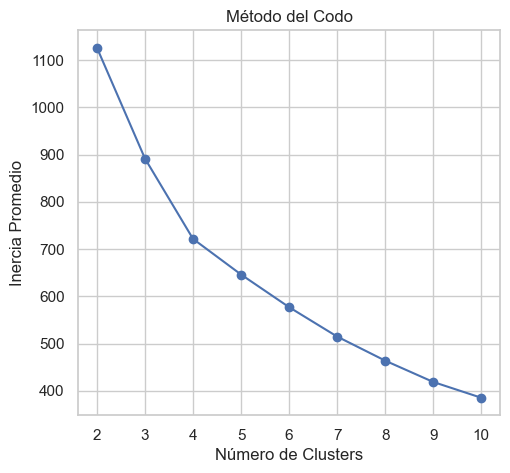

In [802]:
# Plot resultados
plt.figure(figsize=(12, 5))

# Elbow (Inertia)
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia_avg, marker='o')
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia Promedio")
plt.title("Método del Codo")

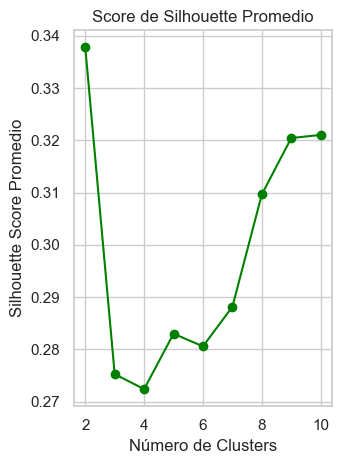

In [803]:
# Silhouette
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, marker='o', color='green')
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score Promedio")
plt.title("Score de Silhouette Promedio")

plt.tight_layout()
plt.show()

In [804]:
# Elegir mejor número de clusters según mayor silhouette
best_k = range_n_clusters[np.argmax(silhouette_avg)]
print(f"✅ Mejor número de clusters (basado en silhouette): {best_k}")

✅ Mejor número de clusters (basado en silhouette): 2


In [805]:
# Entrenar KMeans definitivo con ese k y múltiples inicializaciones
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=50)
labels_final = kmeans_final.fit_predict(X_pca)

# Resultado en DataFrame
df_pca_resultado = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_pca_resultado['cluster'] = labels_final
df_pca_resultado['Especie'] = resumen_merge['Especie'].values  # si el índice está alineado


In [806]:
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=50)
labels_final = kmeans_final.fit_predict(X_pca)

# PCA dataframe for plotting
df_pca_resultado = pd.DataFrame(
    X_pca[:, :5],
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5']
)

df_pca_resultado['cluster'] = labels_final
df_pca_resultado['Especie'] = df_pca['Especie'].reset_index(drop=True).values

In [807]:
# Cluster dataframe for interpretation
df_cluster = df_pca.reset_index(drop=True).copy()
df_cluster['cluster'] = labels_final

print("df_cluster created")
print(df_cluster.shape)
print(df_cluster[['Especie', 'cluster']].head())

df_cluster created
(184, 26)
                    Especie  cluster
0  Myioborus_melanocephalus        1
1  Myioborus_melanocephalus        0
2  Myioborus_melanocephalus        1
3  Myioborus_melanocephalus        1
4  Myioborus_melanocephalus        1


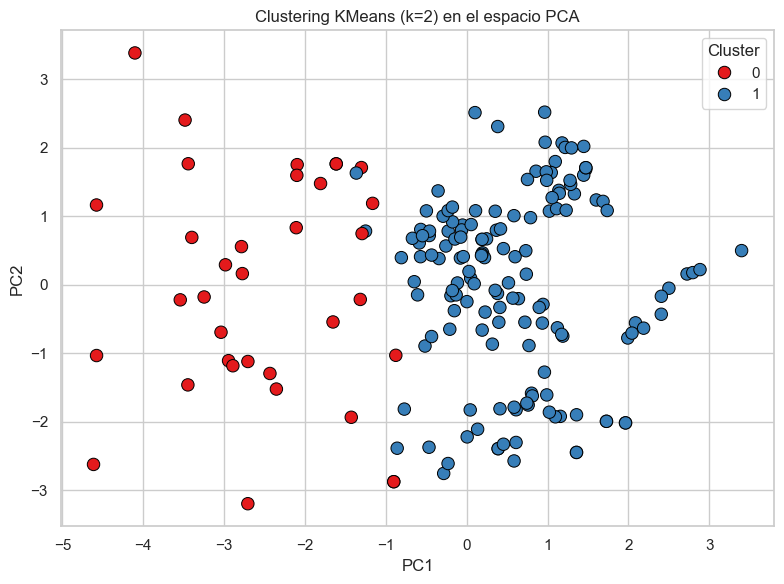

In [808]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca_resultado,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=80,
    edgecolor='black'
)

plt.title('Clustering KMeans (k=2) en el espacio PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

In [809]:
# Cluster dataframe for interpretation
df_cluster = df_pca.reset_index(drop=True).copy()
df_cluster['cluster'] = labels_final

# Species distribution by cluster
tabla = pd.crosstab(df_cluster['cluster'], df_cluster['Especie'])
print(tabla)

# Proportions within each cluster
proporcion = tabla.div(tabla.sum(axis=1), axis=0)
print(proporcion.round(2))


Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                               3                  26                  6
1                              33                 114                  2
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                            0.09                0.74               0.17
1                            0.22                0.77               0.01


In [810]:
chi2, p, dof, expected = chi2_contingency(tabla)

expected_df = pd.DataFrame(
    expected,
    index=tabla.index,
    columns=tabla.columns
)

residuals = (tabla - expected) / np.sqrt(expected)

print("\nChi-square test:")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

print("\nExpected counts under independence:")
print(expected_df.round(2))

print("\nStandardised residuals:")
print(residuals.round(2))


Chi-square test:
Chi-square = 18.963
df = 2
p-value = 0.0001

Expected counts under independence:
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                            6.85               26.63               1.52
1                           29.15              113.37               6.48

Standardised residuals:
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                           -1.47               -0.12               3.63
1                            0.71                0.06              -1.76


In [811]:
resumen_merge['cluster'] = labels_final

resumen_merge = resumen_merge.reset_index(drop=True)
df_pca_resultado = df_pca_resultado.reset_index(drop=True)

resumen_merge['cluster'] = df_pca_resultado['cluster']

In [812]:
resumen_clusters = df_cluster.groupby('cluster')[columnas_pca].mean().round(2).T

In [813]:
resumen_clusters = df_cluster.groupby('cluster')[columnas_pca].mean().round(2).T
print(resumen_clusters)

cluster                        0        1
nest_attentiveness_day      0.36     0.61
duracion_total_on         213.37   210.56
duracion_intervalo_day    621.71   334.99
avg_duracion_on            25.77    22.05
avg_duracion_off           31.06    12.67
avg_duracion_nocturnal    404.73   707.90
avg_temp_ambient_diaria    17.09    16.30
Elevacion                1890.79  1925.51
Huevo_Peso_g                1.55     1.61


In [814]:
resumen_media = df_cluster.groupby('cluster')[columnas_pca].mean().round(2).T
resumen_std = df_cluster.groupby('cluster')[columnas_pca].std().round(2).T

# Unir ambas tablas
resumen_detallado = resumen_media.copy()
for c in resumen_media.columns:
    resumen_detallado[c] = resumen_media[c].astype(str) + " ± " + resumen_std[c].astype(str)

resumen_detallado.columns = [f"Cluster {c}" for c in resumen_detallado.columns]
print(resumen_detallado)

                                Cluster 0         Cluster 1
nest_attentiveness_day        0.36 ± 0.18       0.61 ± 0.11
duracion_total_on         213.37 ± 130.96   210.56 ± 123.39
duracion_intervalo_day    621.71 ± 289.98   334.99 ± 187.99
avg_duracion_on             25.77 ± 13.17      22.05 ± 7.18
avg_duracion_off            31.06 ± 18.99      12.67 ± 4.33
avg_duracion_nocturnal    404.73 ± 154.01     707.9 ± 58.49
avg_temp_ambient_diaria      17.09 ± 5.93       16.3 ± 4.42
Elevacion                1890.79 ± 460.26  1925.51 ± 554.51
Huevo_Peso_g                  1.55 ± 0.25       1.61 ± 0.23


In [815]:
from scipy.stats import chi2_contingency
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu

In [816]:
# tabla = pd.crosstab(df_pca_resultado['cluster'], df_pca_resultado['Especie'])

chi2, p, dof, expected = chi2_contingency(tabla)

expected_df = pd.DataFrame(expected, index=tabla.index, columns=tabla.columns)
residuals = (tabla - expected) / np.sqrt(expected)

print("Tabla observada:")
print(tabla)
print("\nTabla esperada bajo independencia:")
print(expected_df.round(2))
print("\nResiduos estandarizados:")
print(residuals.round(2))

Tabla observada:
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                               3                  26                  6
1                              33                 114                  2

Tabla esperada bajo independencia:
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                            6.85               26.63               1.52
1                           29.15              113.37               6.48

Residuos estandarizados:
Especie  Myioborus_melanocephalus  Myioborus_miniatus  Myioborus_ornatus
cluster                                                                 
0                           -1.47               -0.12               3.63
1                            0.71                0.06              -1.76


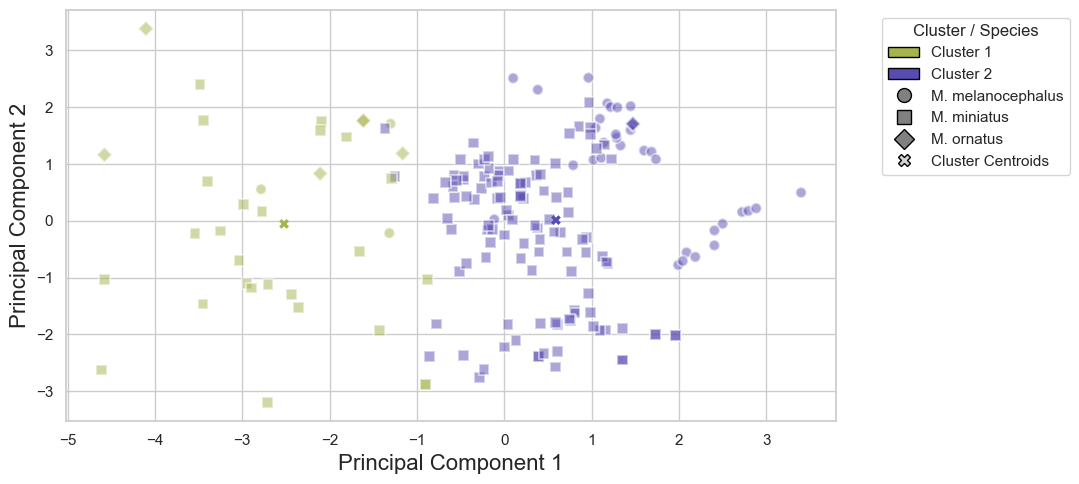

In [817]:
marker_styles = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
unique_species = df_pca_resultado['Especie'].unique()
style_dict = {species: marker_styles[i % len(marker_styles)] for i, species in enumerate(unique_species)}

cluster_labels = {0: "Cluster 1", 1: "Cluster 2"}
species_labels = {
    'Myioborus_melanocephalus': 'M. melanocephalus',
    'Myioborus_miniatus': 'M. miniatus',
    'Myioborus_ornatus': 'M. ornatus'
}

# Colores y estilos
palette = {0: "#A7B34C", 1: "#584CB3"}
marker_styles = ['o', 's', 'D', '^', 'v', 'P', '*', 'X']
unique_species = df_pca_resultado['Especie'].unique()
style_dict = {species: marker_styles[i % len(marker_styles)] for i, species in enumerate(unique_species)}

# Gráfico base
plt.figure(figsize=(11, 5))

sns.scatterplot(
    data=df_pca_resultado,
    x='PC1',
    y='PC2',
    hue='cluster',
    style='Especie',
    palette=palette,
    markers=style_dict,
    s=60,
    linewidth=1.5,
    alpha=0.5,
    legend=False  # Importante: eliminamos la leyenda automática
)

# Centroides
centroids = pd.DataFrame(kmeans_final.cluster_centers_[:, :2], columns=['PC1', 'PC2'])
plt.scatter(
    centroids['PC1'],
    centroids['PC2'],
    c=[palette[0], palette[1]],
    marker='X',
    s=50,
    linewidth=0,
    alpha=1,
    label='Cluster Centroids'
)

# Crear leyenda manual
legend_elements = []

# Clusters
for cluster_id, color in palette.items():
    legend_elements.append(
        Patch(facecolor=color, edgecolor='black', label=cluster_labels[cluster_id])
    )

# Especies
for species, marker in style_dict.items():
    legend_elements.append(
        Line2D([0], [0], marker=marker, color='gray', linestyle='',
               markerfacecolor='gray', markeredgecolor='black',
               markersize=10, label=species_labels.get(species, species))
    )

# Centroides
legend_elements.append(
    Line2D([0], [0], marker='X', color='white', linestyle='',
           markerfacecolor='lightgray', markeredgecolor='black',
           markersize=8, label='Cluster Centroids')
)

plt.title("")
plt.xlabel("Principal Component 1", fontsize=16)
plt.ylabel("Principal Component 2", fontsize=16)
plt.legend(handles=legend_elements, title="Cluster / Species", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/clusterization.png", dpi=300, transparent=True)
plt.show()

In [818]:
df_mwu = resumen_merge.dropna(subset=['Especie', 'Huevo_Peso_g'])

# Verifica que solo hay dos especies
print(df_mwu['Especie'].unique())

# Separar los datos por especie
grupo1 = df_mwu[df_mwu['Especie'] == 'Myioborus_miniatus']['Huevo_Peso_g']
grupo2 = df_mwu[df_mwu['Especie'] == 'Myioborus_melanocephalus']['Huevo_Peso_g']

# Test de Mann-Whitney U (no asume distribución normal)
stat, p = mannwhitneyu(grupo1, grupo2, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {p:.4f}")

['Myioborus_melanocephalus' 'Myioborus_miniatus' 'Myioborus_ornatus']
Mann-Whitney U statistic: 518.0000
P-value: 0.0000


In [819]:
# ============================================================
# 1. Basic descriptive statistics by cluster
# ============================================================

cluster_summary = df_cluster.groupby('cluster')[columnas_pca].agg(
    ['count', 'mean', 'std', 'median', 'min', 'max']
).round(3)

cluster_summary

nest_attentiveness_day                                     \
                         count   mean    std median    min    max   
cluster                                                             
0                           35  0.362  0.176  0.364  0.034  0.771   
1                          149  0.614  0.105  0.630  0.116  0.969   

        duracion_total_on                           ... Elevacion          \
                    count     mean      std median  ...       std  median   
cluster                                             ...                     
0                      35  213.371  130.960  189.0  ...   460.262  1735.0   
1                     149  210.557  123.388  257.0  ...   554.508  1684.0   

                        Huevo_Peso_g                                   
            min     max        count   mean    std median   min   max  
cluster                                                                
0        1405.0  2986.0           35  1.553  0.254   1.50  0.71  2.04  
1        1356.0  2986.0          149  1.612  0.234   1.51  1.35  2.30  

[2 rows x 54 columns]

In [820]:
resumen_media = df_cluster.groupby('cluster')[columnas_pca].mean().round(2).T
resumen_std = df_cluster.groupby('cluster')[columnas_pca].std().round(2).T

resumen_detallado = resumen_media.copy()

for c in resumen_media.columns:
    resumen_detallado[c] = (
        resumen_media[c].astype(str) + " ± " + resumen_std[c].astype(str)
    )

resumen_detallado.columns = [f"Cluster {c}" for c in resumen_detallado.columns]

print(resumen_detallado)

                                Cluster 0         Cluster 1
nest_attentiveness_day        0.36 ± 0.18       0.61 ± 0.11
duracion_total_on         213.37 ± 130.96   210.56 ± 123.39
duracion_intervalo_day    621.71 ± 289.98   334.99 ± 187.99
avg_duracion_on             25.77 ± 13.17      22.05 ± 7.18
avg_duracion_off            31.06 ± 18.99      12.67 ± 4.33
avg_duracion_nocturnal    404.73 ± 154.01     707.9 ± 58.49
avg_temp_ambient_diaria      17.09 ± 5.93       16.3 ± 4.42
Elevacion                1890.79 ± 460.26  1925.51 ± 554.51
Huevo_Peso_g                  1.55 ± 0.25       1.61 ± 0.23


In [821]:
scaler_profile = StandardScaler()

X_profile_scaled = scaler_profile.fit_transform(df_cluster[columnas_pca])

df_scaled_profile = pd.DataFrame(
    X_profile_scaled,
    columns=columnas_pca
)

df_scaled_profile['cluster'] = df_cluster['cluster'].values

perfil_z = df_scaled_profile.groupby('cluster')[columnas_pca].mean().T
perfil_z.columns = [f"Cluster {c}" for c in perfil_z.columns]

print(perfil_z.round(2))

                         Cluster 0  Cluster 1
nest_attentiveness_day       -1.31       0.31
duracion_total_on             0.02      -0.00
duracion_intervalo_day        0.98      -0.23
avg_duracion_on               0.35      -0.08
avg_duracion_off              1.29      -0.30
avg_duracion_nocturnal       -1.68       0.40
avg_temp_ambient_diaria       0.13      -0.03
Elevacion                    -0.05       0.01
Huevo_Peso_g                 -0.20       0.05


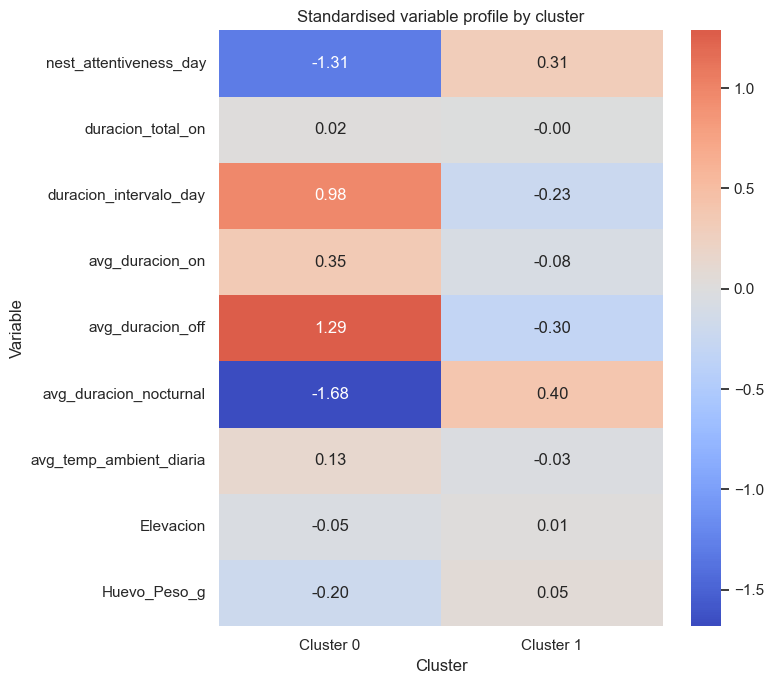

In [822]:
plt.figure(figsize=(8, 7))

sns.heatmap(
    perfil_z,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f"
)

plt.title("Standardised variable profile by cluster")
plt.xlabel("Cluster")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [823]:
cluster_z_means = df_scaled_profile.groupby('cluster')[columnas_pca].mean()

diferencia_z = cluster_z_means.loc[1] - cluster_z_means.loc[0]

drivers_clusters = pd.DataFrame({
    'variable': diferencia_z.index,
    'cluster_0_z_mean': cluster_z_means.loc[0].values,
    'cluster_1_z_mean': cluster_z_means.loc[1].values,
    'difference_cluster1_minus_cluster0_z': diferencia_z.values,
    'absolute_difference': diferencia_z.abs().values
}).sort_values('absolute_difference', ascending=False)

print(drivers_clusters.round(3))

                  variable  cluster_0_z_mean  cluster_1_z_mean  \
5   avg_duracion_nocturnal            -1.682             0.395   
0   nest_attentiveness_day            -1.306             0.307   
4         avg_duracion_off             1.287            -0.302   
2   duracion_intervalo_day             0.976            -0.229   
3          avg_duracion_on             0.346            -0.081   
8             Huevo_Peso_g            -0.202             0.047   
6  avg_temp_ambient_diaria             0.135            -0.032   
7                Elevacion            -0.053             0.012   
1        duracion_total_on             0.018            -0.004   

   difference_cluster1_minus_cluster0_z  absolute_difference  
5                                 2.078                2.078  
0                                 1.612                1.612  
4                                -1.590                1.590  
2                                -1.205                1.205  
3                       

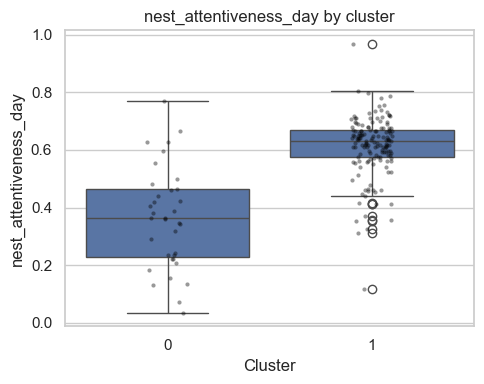

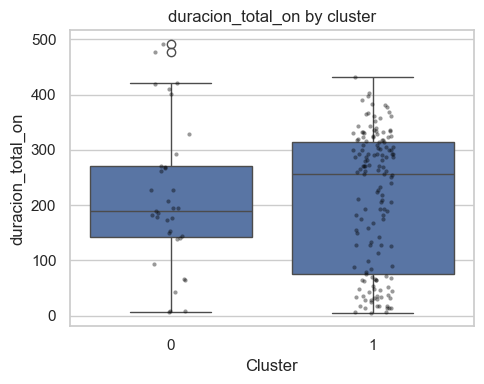

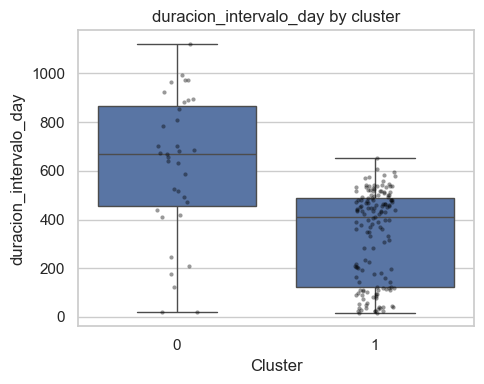

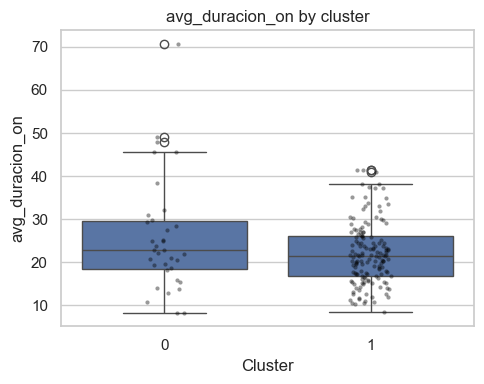

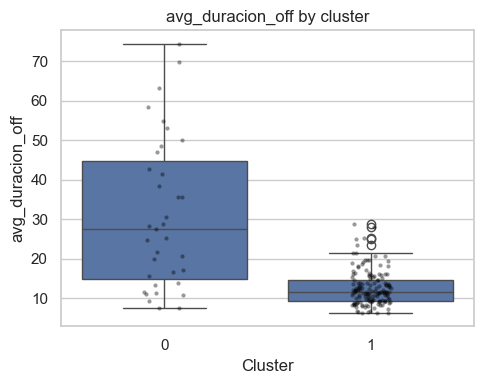

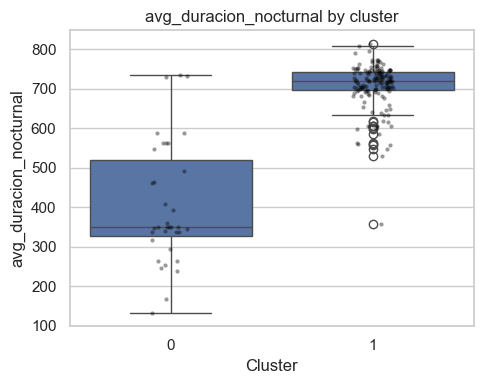

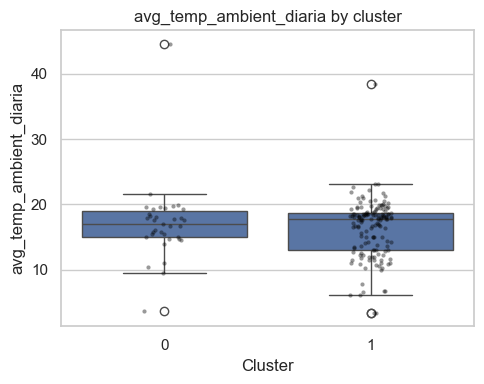

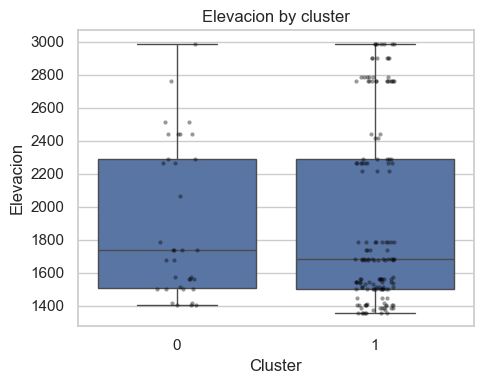

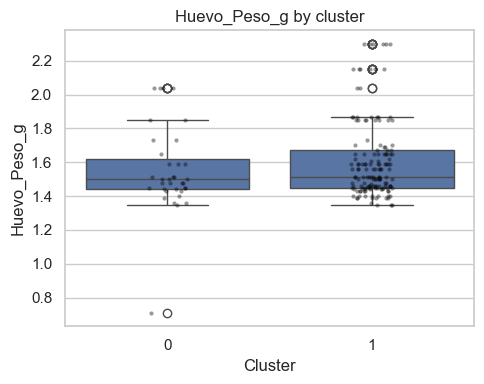

In [824]:
for var in columnas_pca:
    plt.figure(figsize=(5, 4))

    sns.boxplot(
        data=df_cluster,
        x='cluster',
        y=var
    )

    sns.stripplot(
        data=df_cluster,
        x='cluster',
        y=var,
        color='black',
        alpha=0.4,
        size=3,
        jitter=True
    )

    plt.title(f"{var} by cluster")
    plt.xlabel("Cluster")
    plt.ylabel(var)
    plt.tight_layout()
    plt.show()

nest_attentiveness_day avg_duracion_nocturnal vendria siendo la mas importante para trabajar en una diferencia general de los dos cluster y especies. Eso lo podemos ver en general en el siguiente notebook

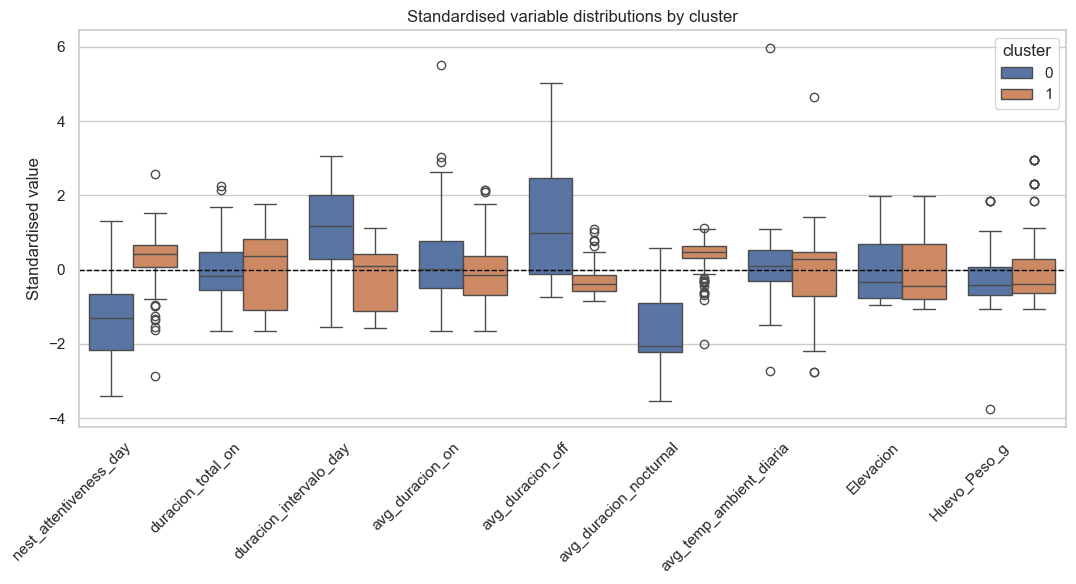

In [825]:
df_long_z = df_scaled_profile.melt(
    id_vars='cluster',
    value_vars=columnas_pca,
    var_name='variable',
    value_name='z_score'
)

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df_long_z,
    x='variable',
    y='z_score',
    hue='cluster'
)

plt.axhline(0, linestyle='--', color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Standardised value")
plt.xlabel("")
plt.title("Standardised variable distributions by cluster")
plt.tight_layout()
plt.show()